In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

# Primer

## What is WUENIC?
- Since 2001, WHO and UNICEF publish coverage estimates at country level
- Triangulation
    - Data sources
        - Administrative reports
        - "Official government estimates"
        - Survey evidence
    - Calculation
      - Add contextual information
      - Derive most likely figure
      - No confidence interval around the numbers but rather a "Grade of Confidence" figure

## The Data
- Administrative reports (Joint Reporting Form)
    - Who produces it?  Health facilities (monthly tally sheets) $\rightarrow$ District health offices (compile and transmit via DHIS2, District Vaccine Data Management Tool, or DVD-MT, or Excel) $\rightarrow$ MoH EPI (aggregates to national totals through JRF each Mar-May for previous calendar year) $\rightarrow$ WHO/UNICEF (validate internal consistency, e.g. $\ngtr$100%, logical age ranges)
    - Custodian?  WHO & UNICEF
    - Quantitative/Qualitative?  Quantitative
    - Frequency?  Annual
    - Components?  Numerator (surviving infants, pregnant women), Denominator (reported target population), result: "Administrative Coverage" =$\dfrac{\text{doses given}}{\text{target population}} \times 10$
    - Known limitations/biases:
        - Denominator errors (especially census-outdated populations)
        - Over-reporting (missed outreach or private sector)
        - Rarely adjusted for age-eligibility or multiple doses
        - Can exceed 100%
    - Typical Use in WUENIC?  Baseline trend, but is weighed cautiously due to data system limitations; subject to validation
- Official government estimates
    - Who produces it?  MoH/EPI/NITAG (National Immunization Technical Advisory Group)
    - Custodian?  WHO/UNICEF country offices
    - Quantitative/Qualitative?  Quantitative
    - Frequency?  Annual (Optional)
    - Components?  MoH reviews admin data (above) then issues an "official estimate"
    - Typical Use in WUENIC?  Used if endorsed and evidence-based
- Survey (DHS, MICS, NICS, etc.)
    - Who produces it?  National Statistics Office/MoH
    - Custodian?  WHO/UNICEF
    - Quantitative/Qualitative? Quantitative
    - Frequency?  $\approx$ 5-yearly
    - Typical Use in WUENIC?  Anchor for adjusting time trends
- Contextual information
    - Who produces it?  WHO/UNICEF field teams, partners
    - Custodian?  WHO/UNICEF
    - Quantitative/Qualitative?  Qualitative & quantitative
    - Frequency?  Continous
    - Typical Use in WUENIC?  Explains anomalies, guides confidence grade

In [2]:
path = "wuenic_input_to_pdf.xlsx"
df = pd.read_excel(path, sheet_name="wuenic_master")

print(df.shape)
print(df.dtypes)
df.head()                

(47103, 14)
Country                    object
ISOCountryCode             object
Vaccine                    object
Year                        int64
WUENIC                      int64
WUENICPreviousRevision    float64
GradeOfConfidence           int64
AdministrativeCoverage    float64
GovernmentEstimate        float64
ChildrenVaccinated        float64
ChildrenInTarget          float64
BirthsUNPD                  int64
SurvivingInfantsUNPD        int64
Comment                    object
dtype: object


,Country,ISOCountryCode,Vaccine,Year,WUENIC,WUENICPreviousRevision,GradeOfConfidence,AdministrativeCoverage,GovernmentEstimate,ChildrenVaccinated,ChildrenInTarget,BirthsUNPD,SurvivingInfantsUNPD,Comment
0,Afghanistan,AFG,BCG,1997,43,43.0,2,43.0,NaN,NaN,NaN,961674,896754,Legacy estimate. GoC=R+
1,Afghanistan,AFG,BCG,1998,35,35.0,2,NaN,35.0,NaN,NaN,985909,920265,Estimate informed by reported data. EPI Covera...
2,Afghanistan,AFG,BCG,1999,38,38.0,2,43.0,38.0,381008.0,878443.0,1013252,947416,Estimate informed by reported data. Afghanista...
3,Afghanistan,AFG,BCG,2000,30,30.0,2,38.0,30.0,412754.0,1079435.0,1036525,970393,Estimate informed by reported data. Data refle...
4,Afghanistan,AFG,BCG,2001,43,43.0,2,66.0,43.0,494628.0,747690.0,1006562,943488,Estimate informed by reported data. GoC=R+ D+


# Step 1: Pandas (Wrangling the data into shape)

Pandas is the workhorse.  Every other step depends on getting the data into a clean DataFrame, so we will spend real time here.  The five things every data scientist need to do with a new dataset: inspect it, clean it, reshape it, group it, and check it makes sense.

## Step 1.1: Inspect

In [3]:
df.info() # column types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47103 entries, 0 to 47102
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 47103 non-null  object 
 1   ISOCountryCode          47103 non-null  object 
 2   Vaccine                 47103 non-null  object 
 3   Year                    47103 non-null  int64  
 4   WUENIC                  47103 non-null  int64  
 5   WUENICPreviousRevision  44522 non-null  float64
 6   GradeOfConfidence       47103 non-null  int64  
 7   AdministrativeCoverage  38313 non-null  float64
 8   GovernmentEstimate      39051 non-null  float64
 9   ChildrenVaccinated      35985 non-null  float64
 10  ChildrenInTarget        36134 non-null  float64
 11  BirthsUNPD              47103 non-null  int64  
 12  SurvivingInfantsUNPD    47103 non-null  int64  
 13  Comment                 47103 non-null  object 
dtypes: float64(5), int64(5), object(4)
mem

In [4]:
df.describe() # numeric summary

,Year,WUENIC,WUENICPreviousRevision,GradeOfConfidence,AdministrativeCoverage,GovernmentEstimate,ChildrenVaccinated,ChildrenInTarget,BirthsUNPD,SurvivingInfantsUNPD
count,47103.000000,47103.000000,44522.000000,47103.000000,38313.000000,39051.000000,3.598500e+04,3.613400e+04,4.710300e+04,4.710300e+04
mean,2013.247373,85.670594,85.766071,1.556207,87.587164,87.248624,8.006265e+05,2.703841e+08,6.844003e+05,6.654696e+05
std,8.107680,17.077893,17.116565,0.628011,16.972735,15.809826,3.299712e+07,5.126058e+10,2.219116e+06,2.154227e+06
min,1997.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-9.999000e+03,-9.999000e+03,2.500000e+01,2.500000e+01
25%,2007.000000,81.000000,81.000000,1.000000,83.000000,83.000000,2.248800e+04,2.807500e+04,2.903400e+04,2.846900e+04
50%,2014.000000,92.000000,92.000000,1.000000,93.000000,93.000000,1.269700e+05,1.492430e+05,1.331880e+05,1.313420e+05
75%,2020.000000,97.000000,97.000000,2.000000,98.000000,97.000000,5.055660e+05,6.037070e+05,5.775070e+05,5.620360e+05
max,2025.000000,99.000000,99.000000,3.000000,890.000000,169.000000,6.247666e+09,9.744096e+12,2.932493e+07,2.787432e+07


In [5]:
df.isna().sum() # missing values per column

Country                       0
ISOCountryCode                0
Vaccine                       0
Year                          0
WUENIC                        0
WUENICPreviousRevision     2581
GradeOfConfidence             0
AdministrativeCoverage     8790
GovernmentEstimate         8052
ChildrenVaccinated        11118
ChildrenInTarget          10969
BirthsUNPD                    0
SurvivingInfantsUNPD          0
Comment                       0
dtype: int64

In [6]:
df["Vaccine"].value_counts()

Vaccine
DTP1     5623
DTP3     5623
MCV1     5623
HepB3    4673
BCG      4572
Hib3     4120
RCV1     3947
MCV2     3676
PCVC     2061
IPV1     2029
HepBB    1988
RotaC    1437
YFV       892
IPVC      730
MENGA     109
Name: count, dtype: int64

In [7]:
df["Year"].agg(["min", "max"])

min    1997
max    2025
Name: Year, dtype: int64

## Step 1.2: Clean and add helpful columns

- WUENIC is currently an integer percentage.
- Convert it to a proportion (0 to 1) for any modelling that expects probabilities, but keep the original column for plotting.
- Compute a one-year change column for trend analysis.
- Add a flag for under-90 coverage, which is the common benchmark for herd immunity for vaccines like measles.

In [8]:
# reformat the data frame to be sorted by country, then vaccine, then year

df = df.sort_values(["Country", "Vaccine", "Year"]).reset_index(drop=True)
df.head()

,Country,ISOCountryCode,Vaccine,Year,WUENIC,WUENICPreviousRevision,GradeOfConfidence,AdministrativeCoverage,GovernmentEstimate,ChildrenVaccinated,ChildrenInTarget,BirthsUNPD,SurvivingInfantsUNPD,Comment
0,Afghanistan,AFG,BCG,1997,43,43.0,2,43.0,NaN,NaN,NaN,961674,896754,Legacy estimate. GoC=R+
1,Afghanistan,AFG,BCG,1998,35,35.0,2,NaN,35.0,NaN,NaN,985909,920265,Estimate informed by reported data. EPI Covera...
2,Afghanistan,AFG,BCG,1999,38,38.0,2,43.0,38.0,381008.0,878443.0,1013252,947416,Estimate informed by reported data. Afghanista...
3,Afghanistan,AFG,BCG,2000,30,30.0,2,38.0,30.0,412754.0,1079435.0,1036525,970393,Estimate informed by reported data. Data refle...
4,Afghanistan,AFG,BCG,2001,43,43.0,2,66.0,43.0,494628.0,747690.0,1006562,943488,Estimate informed by reported data. GoC=R+ D+


In [9]:
# create the WUENIC figure to a proportion 0 to 1
df["coverage_prop"] = df["WUENIC"] / 100
df.head()

,Country,ISOCountryCode,Vaccine,Year,WUENIC,WUENICPreviousRevision,GradeOfConfidence,AdministrativeCoverage,GovernmentEstimate,ChildrenVaccinated,ChildrenInTarget,BirthsUNPD,SurvivingInfantsUNPD,Comment,coverage_prop
0,Afghanistan,AFG,BCG,1997,43,43.0,2,43.0,NaN,NaN,NaN,961674,896754,Legacy estimate. GoC=R+,0.43
1,Afghanistan,AFG,BCG,1998,35,35.0,2,NaN,35.0,NaN,NaN,985909,920265,Estimate informed by reported data. EPI Covera...,0.35
2,Afghanistan,AFG,BCG,1999,38,38.0,2,43.0,38.0,381008.0,878443.0,1013252,947416,Estimate informed by reported data. Afghanista...,0.38
3,Afghanistan,AFG,BCG,2000,30,30.0,2,38.0,30.0,412754.0,1079435.0,1036525,970393,Estimate informed by reported data. Data refle...,0.30
4,Afghanistan,AFG,BCG,2001,43,43.0,2,66.0,43.0,494628.0,747690.0,1006562,943488,Estimate informed by reported data. GoC=R+ D+,0.43


In [10]:
# year over year change WITHIN each country-vaccine series
df["delta"] = df.groupby(["Country", "Vaccine"])["WUENIC"].diff()
df.head()

,Country,ISOCountryCode,Vaccine,Year,WUENIC,WUENICPreviousRevision,GradeOfConfidence,AdministrativeCoverage,GovernmentEstimate,ChildrenVaccinated,ChildrenInTarget,BirthsUNPD,SurvivingInfantsUNPD,Comment,coverage_prop,delta
0,Afghanistan,AFG,BCG,1997,43,43.0,2,43.0,NaN,NaN,NaN,961674,896754,Legacy estimate. GoC=R+,0.43,NaN
1,Afghanistan,AFG,BCG,1998,35,35.0,2,NaN,35.0,NaN,NaN,985909,920265,Estimate informed by reported data. EPI Covera...,0.35,-8.0
2,Afghanistan,AFG,BCG,1999,38,38.0,2,43.0,38.0,381008.0,878443.0,1013252,947416,Estimate informed by reported data. Afghanista...,0.38,3.0
3,Afghanistan,AFG,BCG,2000,30,30.0,2,38.0,30.0,412754.0,1079435.0,1036525,970393,Estimate informed by reported data. Data refle...,0.30,-8.0
4,Afghanistan,AFG,BCG,2001,43,43.0,2,66.0,43.0,494628.0,747690.0,1006562,943488,Estimate informed by reported data. GoC=R+ D+,0.43,13.0


In [11]:
# three-year rolling mean per country-vaccine
df["rolling_3"] = (
    df.groupby(["Country", "Vaccine"])["WUENIC"]
    .transform(lambda s: s.rolling(3, min_periods=1).mean())
)

df.head()

,Country,ISOCountryCode,Vaccine,Year,WUENIC,WUENICPreviousRevision,GradeOfConfidence,AdministrativeCoverage,GovernmentEstimate,ChildrenVaccinated,ChildrenInTarget,BirthsUNPD,SurvivingInfantsUNPD,Comment,coverage_prop,delta,rolling_3
0,Afghanistan,AFG,BCG,1997,43,43.0,2,43.0,NaN,NaN,NaN,961674,896754,Legacy estimate. GoC=R+,0.43,NaN,43.000000
1,Afghanistan,AFG,BCG,1998,35,35.0,2,NaN,35.0,NaN,NaN,985909,920265,Estimate informed by reported data. EPI Covera...,0.35,-8.0,39.000000
2,Afghanistan,AFG,BCG,1999,38,38.0,2,43.0,38.0,381008.0,878443.0,1013252,947416,Estimate informed by reported data. Afghanista...,0.38,3.0,38.666667
3,Afghanistan,AFG,BCG,2000,30,30.0,2,38.0,30.0,412754.0,1079435.0,1036525,970393,Estimate informed by reported data. Data refle...,0.30,-8.0,34.333333
4,Afghanistan,AFG,BCG,2001,43,43.0,2,66.0,43.0,494628.0,747690.0,1006562,943488,Estimate informed by reported data. GoC=R+ D+,0.43,13.0,37.000000


In [12]:
# below herd immunity levels
df["below_90"] = df["WUENIC"] < 90
df.head()

,Country,ISOCountryCode,Vaccine,Year,WUENIC,WUENICPreviousRevision,GradeOfConfidence,AdministrativeCoverage,GovernmentEstimate,ChildrenVaccinated,ChildrenInTarget,BirthsUNPD,SurvivingInfantsUNPD,Comment,coverage_prop,delta,rolling_3,below_90
0,Afghanistan,AFG,BCG,1997,43,43.0,2,43.0,NaN,NaN,NaN,961674,896754,Legacy estimate. GoC=R+,0.43,NaN,43.000000,True
1,Afghanistan,AFG,BCG,1998,35,35.0,2,NaN,35.0,NaN,NaN,985909,920265,Estimate informed by reported data. EPI Covera...,0.35,-8.0,39.000000,True
2,Afghanistan,AFG,BCG,1999,38,38.0,2,43.0,38.0,381008.0,878443.0,1013252,947416,Estimate informed by reported data. Afghanista...,0.38,3.0,38.666667,True
3,Afghanistan,AFG,BCG,2000,30,30.0,2,38.0,30.0,412754.0,1079435.0,1036525,970393,Estimate informed by reported data. Data refle...,0.30,-8.0,34.333333,True
4,Afghanistan,AFG,BCG,2001,43,43.0,2,66.0,43.0,494628.0,747690.0,1006562,943488,Estimate informed by reported data. GoC=R+ D+,0.43,13.0,37.000000,True


### Python stuff

#### Assignment
`df = df.sort_values(["Country", "Vaccine", "Year"]).reset_index(drop=True)`

The `df =` is an assignment.  It permanently reorders the DataFrame.


#### `.groupby`
`df["delta"] = df.groupby(["Country", "Vaccine"])["WUENIC"].diff()`

What is `.groupby` doing?  `.diff()` will take the difference of adjacent lines (first line would give `NaN`).  So, if you don't do `.groupby` you would differences that don't have any meaning like the difference between DTP3 and HepB.

Other key Pandas functions where `.groupby` is critical are as follows:
- `.diff()`
- `.shift` lookups of values from N rows ago (useful for building lagged features for machine learning)
- `.cumsum()`, `.cummax()`, `.cumcount()` -- running totals and counts
- `rolling(3).mean()` -- moving averages
- `pct_change()` -- percentage change from previous row
- `fillna(method="ffill")` -- filling missing values with the last known value

#### `lambda` a small unnamed function
`df['rolling_3"] = (df.groupby(["Country", "Vaccine"])["WUENIC"].transform(lambda s: s.rolling(3, min_periods=1).mean()))`

`lambda` is Python syntax for creating a function inline, without giving it a name.  The two lines below define functions that do exactly the same thing.

Everything left of the colon is the parameter list.  Everything right of the colon is a single expression whose value becomes the return value.  There's no `return` keyword because a lambda can only be one expression--you can't put multiple statements in it.

`s: ` is just a parameter name.

Why bother? Two reasons. 
- First, when you need a tiny function just once, defining it with `def` on its own line and giving it a name adds visual noise.
- Second — and more importantly — many pandas methods (like `transform`, `apply`, `map`, `filter`) accept a function as an argument.

You need to hand them a function object, and `lambda` is the compact way to build one on the spot.

#### `transform` - apply a function group-by-group, keep original shape

This is the star of the show. `transform` is one of three methods you can chain off a groupby object (the others are `agg` and `apply`). Each has a different job.

Recall from the earlier discussion: `df.groupby(["Country", "Vaccine"])["WUENIC"]` produces a "grouped Series" — conceptually, one WUENIC time series per country-vaccine pair. What do you want to do with those groups?

- `agg` collapses each group to a single value. Group of 28 years → one number (mean, max, count, whatever). Result is one row per group.
- `transform` returns a value for every input row, computed within the group. Group of 28 years → 28 values. Result has the same length as the original DataFrame.
- `apply` is the flexible one — it lets you return whatever you want per group.

For a rolling mean, you need 28 output values per country-vaccine (one for each year), and you need them to line up with the original rows so you can assign them back as a new column. That's exactly what `transform` is designed for.

In [13]:
# understand better lambda

demo = pd.DataFrame({
    "Country": ["A", "A", "A", "A", "B", "B", "B", "B"],
    "Year": [2020, 2021, 2022, 2023, 2020, 2021, 2022, 2023],
    "WUENIC": [10, 20, 30, 40, 50, 60, 70, 80]
})

demo["rolling_3"] = (
    demo.groupby("Country")["WUENIC"]
    .transform(lambda s: s.rolling(4, min_periods=1).mean())
)

print(demo)

  Country  Year  WUENIC  rolling_3
0       A  2020      10       10.0
1       A  2021      20       15.0
2       A  2022      30       20.0
3       A  2023      40       25.0
4       B  2020      50       50.0
5       B  2021      60       55.0
6       B  2022      70       60.0
7       B  2023      80       65.0


## Step 1.3: Reshape--long vs wide

In [14]:
# one row per country, one column per vaccine, value = 2025 coverage
wide_2025 = df[df["Year"] == 2025].pivot(
    index="Country",
    columns="Vaccine",
    values="WUENIC"
)

wide_2025.head()

Vaccine,BCG,DTP1,DTP3,HepB3,HepBB,Hib3,IPV1,IPVC,MCV1,MCV2,MENGA,PCVC,RCV1,RotaC,YFV
Country,,,,,,,,,,,,,,,
Afghanistan,73.0,67.0,61.0,61.0,64.0,61.0,62.0,50.0,56.0,42.0,NaN,63.0,NaN,60.0,NaN
Albania,99.0,98.0,96.0,96.0,98.0,96.0,98.0,96.0,81.0,88.0,NaN,81.0,81.0,96.0,NaN
Algeria,98.0,99.0,94.0,94.0,93.0,94.0,99.0,94.0,96.0,92.0,NaN,95.0,96.0,NaN,NaN
Andorra,NaN,98.0,98.0,97.0,NaN,97.0,98.0,98.0,99.0,96.0,NaN,93.0,99.0,90.0,NaN
Angola,77.0,67.0,52.0,52.0,NaN,52.0,47.0,36.0,71.0,46.0,NaN,54.0,71.0,48.0,48.0


In [15]:
# going the other way with 'melt' when you have a wide table and you want long-form for plotting:

df_long = wide_2025.reset_index().melt(
    id_vars="Country",
    var_name="Vaccine",
    value_name="WUENIC"
)

df_long.head()

,Country,Vaccine,WUENIC
0,Afghanistan,BCG,73.0
1,Albania,BCG,99.0
2,Algeria,BCG,98.0
3,Andorra,BCG,NaN
4,Angola,BCG,77.0


## Step 1.4: Group and aggregate

In [16]:
global_trend = df.groupby(["Vaccine", "Year"])["WUENIC"].mean().reset_index()
print(global_trend.head(20))

# Top-5 worst coverage countries for measles MCV1 in 2025
worst = (df.query("Vaccine == 'MCV1' and Year == 2025")
           .nsmallest(5, "WUENIC")
           [["Country", "WUENIC"]])

print(worst)

   Vaccine  Year     WUENIC
0      BCG  1997  85.961538
1      BCG  1998  86.256410
2      BCG  1999  87.037975
3      BCG  2000  87.291139
4      BCG  2001  87.474684
5      BCG  2002  87.362500
6      BCG  2003  88.262500
7      BCG  2004  88.850000
8      BCG  2005  89.496855
9      BCG  2006  90.397516
10     BCG  2007  90.689441
11     BCG  2008  91.433962
12     BCG  2009  91.327044
13     BCG  2010  91.626582
14     BCG  2011  91.566038
15     BCG  2012  92.201258
16     BCG  2013  91.493671
17     BCG  2014  91.234177
18     BCG  2015  90.601266
19     BCG  2016  90.464968
                        Country  WUENIC
27622                Montenegro      13
46325                     Yemen      41
7986   Central African Republic      44
32251          Papua New Guinea      45
5303     Bosnia and Herzegovina      46


In [17]:
# Which countries fell the most between 2019 and 2025?  COVID disrupted RI globally; let's quantify it.  Use pivot_table for clarity

pivot = df.pivot_table(
    index="Country", columns="Year", values="WUENIC",
    aggfunc="mean" # in case of any duplicates
)

covid_drop = (pivot[2019] - pivot[2025]).sort_values(ascending=False)
covid_drop.head(10)

Country
Nauru                                 23.183333
Sudan                                 21.441558
South Africa                          18.316667
Romania                               17.181818
Lebanon                               16.333333
Yemen                                 16.075758
Kiribati                              15.730769
Maldives                              15.450000
Belize                                14.630769
Venezuela (Bolivarian Republic of)    14.500000
dtype: float64

In [18]:
pivot.head(10)

Year,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,39.25,35.250000,36.000000,32.250000,43.000000,44.750000,47.500000,44.600000,50.000000,52.800000,...,59.800000,59.800000,62.363636,58.636364,57.272727,51.083333,57.166667,58.833333,60.833333,60.000000
Albania,96.80,93.000000,93.800000,96.166667,95.125000,96.250000,95.375000,97.250000,97.875000,96.625000,...,98.363636,98.363636,97.818182,97.727273,96.250000,95.307692,94.769231,94.076923,93.538462,92.615385
Algeria,92.75,89.500000,87.600000,87.200000,86.800000,90.200000,91.600000,90.000000,91.000000,94.000000,...,91.200000,92.272727,89.909091,88.454545,86.636364,84.636364,82.727273,89.750000,93.500000,95.333333
Andorra,88.20,83.333333,89.166667,94.166667,93.666667,94.666667,94.000000,94.714286,94.000000,92.714286,...,95.800000,98.222222,97.888889,98.222222,97.555556,98.100000,97.100000,97.400000,97.600000,96.636364
Angola,58.40,54.800000,44.600000,44.000000,57.600000,61.600000,56.400000,61.400000,49.200000,50.200000,...,48.800000,51.900000,59.166667,60.583333,54.833333,49.083333,46.153846,58.230769,51.923077,55.461538
Antigua and Barbuda,96.00,99.000000,99.000000,95.750000,97.166667,98.333333,98.666667,97.333333,91.428571,94.571429,...,87.875000,96.125000,96.250000,94.875000,92.375000,82.000000,90.600000,89.700000,93.300000,93.300000
Argentina,93.80,86.166667,93.000000,85.000000,84.000000,89.500000,93.875000,93.777778,93.000000,90.555556,...,79.153846,82.076923,82.769231,77.230769,69.846154,76.214286,79.071429,65.500000,70.500000,70.500000
Armenia,87.00,91.000000,93.000000,89.285714,91.714286,94.000000,94.125000,93.375000,93.000000,89.000000,...,90.750000,95.333333,94.333333,94.083333,92.750000,94.076923,94.846154,95.230769,95.384615,97.153846
Australia,80.20,82.000000,87.800000,90.400000,92.833333,93.666667,94.000000,92.428571,92.285714,92.714286,...,93.500000,93.900000,94.000000,94.500000,94.500000,94.636364,93.727273,92.818182,87.083333,88.000000


In [19]:
# Multiple aggregations at once.  Use named aggregations for readable output.

summary = df.groupby("Vaccine").agg(
    mean_cov=("WUENIC", "mean"),
    median_cov=("WUENIC", "median"),
    pct_below_90=("below_90", "mean"),
    n_obs=("WUENIC", "size")
).round(2)
summary

,mean_cov,median_cov,pct_below_90,n_obs
Vaccine,,,,
BCG,89.69,95.0,0.31,4572
DTP1,91.55,96.0,0.25,5623
DTP3,86.23,92.0,0.41,5623
HepB3,85.69,92.0,0.42,4673
HepBB,82.67,93.0,0.44,1988
Hib3,86.46,92.0,0.40,4120
IPV1,85.28,94.0,0.38,2029
IPVC,81.67,91.0,0.47,730
MCV1,85.33,91.0,0.44,5623


## Step 1.5: Save a cleaned copy

In [20]:
# once you are happy with the cleaned frame, save it as a parquet file.  Parquet is roughly 10x smaller than CSV, preserves dtypes, and reloads in a fraction of the time

df.to_parquet("wuenic_clean.parquet")
# next time: df = pd.read_parquet("wuenic_clean.parquet")

# NumPy -- vectorized math under the hood

Most of what you do in pandas is NumPy underneath. NumPy gives you the n-dimensional array and a few thousand functions that operate on it without Python-level loops. Three patterns are worth practising deliberately.

## Step 2.1: Vectorized arithmetic

In [21]:
# Compute how many children would have been vaccinated if a country had hit 95% coverage--and how many fewer doses each country gave compared to that target

# Pull a 1D array of surviving infants and the matching coverage
surv = df["SurvivingInfantsUNPD"].to_numpy()
cov = df["WUENIC"].to_numpy() / 100

target_kids = surv * 0.95  # element-wise multiplication
actual_kids = surv * cov
shortfall = np.maximum(target_kids - actual_kids, 0)   # clip negatives

df["shortfall_at_95"] = shortfall
df["shortfall_at_95"].describe()

count    4.710300e+04
mean     1.106011e+05
std      6.564882e+05
min      0.000000e+00
25%      0.000000e+00
50%      8.771000e+02
75%      3.136171e+04
max      2.423821e+07
Name: shortfall_at_95, dtype: float64

## Step 2.2: Boolean masking

Boolean arrays are NumPy's most under-appreciated feature. Anywhere you would write a loop with an if statement, you can usually write a mask instead.

In [22]:
# What share of country-year-antigen observations are 'high coverage' (>=90)?
high = df["WUENIC"].to_numpy() >= 90
print(f"High-coverage share: {high.mean():.3f}")

# Combine masks with & and |
recent_high = (df["Year"] >= 2020) & high
print(f"High coverage since 2020: {recent_high.mean():.3f}")

High-coverage share: 0.590
High coverage since 2020: 0.147


## Step 2.3: Broadcasting and reductions

Reshape a long series into a 2D matrix and let NumPy do the rest. Here we compute the year-on-year change in mean DTP3 coverage globally without a single explicit loop.

In [23]:
# build a country x year matrix for DTP3
dtp3 = df.query("Vaccine == 'DTP3'").pivot(
                index="Country", columns="Year", values="WUENIC"
).to_numpy()

# np.nanmean ignores missing values along an axis
global_mean = np.nanmean(dtp3, axis=0) #one value per year
yoy = np.diff(global_mean) #one fewer value
print("Years (1998-2025) YoY change:", yoy.round(2))

Years (1998-2025) YoY change: [ 0.7  -0.33  0.99  1.03  0.43  0.87  0.85  1.44  0.32  1.05  0.26  0.48
  0.23  0.25  0.27 -0.55 -0.55 -0.15  0.21 -0.39  0.28  0.37 -2.48 -0.89
  0.96  0.06  0.26  0.06]


### Python stuff

#### When to drop into NumPy

Stay in pandas while you have meaningful index/column labels. Drop into NumPy when you need a raw matrix (for linear algebra, scikit-learn input, or simulation) or when you need a function that pandas does not wrap (np.gradient, np.fft, np.linalg.svd, np.random sampling, and so on).

`np.gradient` $\rightarrow$  function computes the numerical derivative of an N-dimensional array using second-order accurate central differences. It returns a list of arrays (or a single array if the input is 1D) representing the partial derivatives along each axis, matching the original array's shape.

`np.fft` $\rightarrow$  is a dedicated sub-module in NumPy used to compute the Discrete Fourier Transform (DFT) and its inverse using the highly optimized Fast Fourier Transform (FFT) algorithm. It maps a signal from its original time (or space) domain into the frequency domain.

`np.linalg.svd` $\rightarrow$  computes the Singular Value Decomposition (SVD) of a matrix, factorizing an M × N matrix A into three constituent parts: $(A = U \cdot \Sigma \cdot V^H)$.

# SciPy -- statistical tests and signal smoothing

SciPy gives you the classical stats toolbox. We will use four pieces of it: distributions, hypothesis tests, interpolation, and signal smoothing.

## Step 3.1: Distributions and confidence intervals

Compute a 95% confidence interval for global mean MCV1 coverage in 2024 using the t-distribution.

In [24]:
from scipy import stats

In [25]:
vals = df.query("Vaccine == 'MCV1' and Year == 2025")["WUENIC"].dropna()
n = len(vals)
mean = vals.mean()
se = vals.std(ddof=1) / np.sqrt(n)
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
print(f"MCV1 2025: mean={mean:.2f}, 95% CI=({ci[0]:.2f}, {ci[1]:.2f}), n={n}")

MCV1 2025: mean=85.04, 95% CI=(82.96, 87.11), n=195


### Stats stuff

**The standard error (SE)** measures how much a sample-based estimate is expected to vary from the true population value.

$\dfrac{\sigma}{\sqrt{n}}$

A **t-interval (or t-confidence interval)** is a statistical range used to estimate an unknown population mean when the population standard deviation is unknown and the sample size is small.

## Step 3.2: Hypothesis test--did coverage drop during COVID?

Paired t-test: each country contributes a 2019 value and a 2021 value. The null hypothesis is that the population mean of the differences is zero.

In [26]:
pivot = df.query("Vaccine == 'DTP3'").pivot(
    index="Country", columns="Year", values="WUENIC"
)

paired = pivot[[2019, 2021]].dropna()
t, p = stats.ttest_rel(paired[2019], paired[2021])
print(f"Mean 2019: {paired[2019].mean():.2f}")
print(f"Mean 2021: {paired[2021].mean():.2f}")
print(f"t = {t:.3f}, p = {p:.2e}")

Mean 2019: 88.58
Mean 2021: 85.21
t = 6.688, p = 2.36e-10


**Interpreting your output:**

**The means (88.58 vs. 85.21):** DTP3 coverage dropped by about 3.37 percentage points on average between 2019 and 2021 across whatever pairs you compared (likely countries).

**t = 6.688:** This tells you how many standard errors the observed difference is away from zero. In `scipy.stats.ttest_rel(coverage_2019, coverage_2021)`, a positive t means the first argument (2019) is on average higher than the second (2021) — consistent with coverage dropping. The size of t depends on two things: how big the average difference is, and how consistent that difference is across your pairs (i.e., the variability of the differences). A t of 6.688 is large, meaning the drop is not just present on average but fairly consistent across most of your data points (countries), not driven by a few outliers.

**p = 2.36e-10:** This is the probability of seeing a t-statistic this extreme (or more extreme) if there were actually no true difference between 2019 and 2021. This p-value is astronomically small — far below the usual 0.05 threshold — so you can confidently reject the idea that this is random noise. There's a real, statistically significant drop in DTP3 coverage from 2019 to 2021.

**One nuance worth flagging:** with WUENIC data you likely have a large number of countries (n is large), and t-tests get more powerful — and p-values get smaller — as n grows, even for modest differences. So while p = 2.36e-10 confirms the drop is real and not chance, don't read the tiny p-value itself as "the drop is huge." The 3.37 percentage-point difference is what tells you the *size* of the effect; the p-value only tells you about *confidence* that it's non-zero. Both together give you the full picture: a real, and programmatically meaningful, decline in DTP3 coverage likely tied to COVID-related disruptions.

## Step 3.3: Spearman correlation

Is DTP3 coverage correlated with MCV1 coverage across countries in 2025?  Spearman is safer than Pearson here because coverage is bounded and not necessarily linearly related.

In [27]:
w25 = df[df["Year"] == 2025].pivot(index="Country", columns="Vaccine", values="WUENIC")
rho, p = stats.spearmanr(w25["DTP3"], w25["MCV1"], nan_policy="omit")
print(f"Spearman rho={rho:.3f}, p={p:.2e}")

Spearman rho=0.881, p=9.11e-65


In [28]:
print(w25.columns.tolist())

['BCG', 'DTP1', 'DTP3', 'HepB3', 'HepBB', 'Hib3', 'IPV1', 'IPVC', 'MCV1', 'MCV2', 'MENGA', 'PCVC', 'RCV1', 'RotaC', 'YFV']


In [29]:
result = w25.query("DTP3 >= 80 and MCV1 < 70")
print(result)

Vaccine         BCG  DTP1  DTP3  HepB3  HepBB  Hib3  IPV1  IPVC  MCV1  MCV2  \
Country                                                                       
Guinea-Bissau  82.0  90.0  84.0   84.0    NaN  84.0  75.0   NaN  69.0  36.0   
Mali           88.0  90.0  84.0   84.0    NaN  84.0  76.0  69.0  68.0  52.0   
Suriname        NaN  80.0  80.0   80.0   79.0  80.0  78.0  76.0  67.0  52.0   
Timor-Leste    90.0  89.0  83.0   83.0   76.0  83.0  80.0   NaN  61.0  57.0   

Vaccine        MENGA  PCVC  RCV1  RotaC   YFV  
Country                                        
Guinea-Bissau   65.0  90.0   NaN   86.0  70.0  
Mali            68.0  81.0  68.0   80.0  70.0  
Suriname         NaN   NaN  67.0    NaN  63.0  
Timor-Leste      NaN  82.0  61.0   27.0   NaN  


## Step 3.4: Smoothing a noisy country trajectory

Country-level trajectories can be jumpy. A Savitzky-Golay filter from scipy.signal smooths a series while preserving local shape — much better than a moving average if you care about turning points.

In [30]:
from scipy.signal import savgol_filter

afg = df.query("Country == 'Afghanistan' and Vaccine == 'DTP3'").sort_values("Year")
smooth = savgol_filter(afg["WUENIC"].values, window_length=5, polyorder=2)
afg = afg.assign(smooth=smooth)
afg[["Year", "WUENIC", "smooth"]].head(10)

,Year,WUENIC,smooth
58,1997,28,28.828571
59,1998,27,25.885714
60,1999,27,25.371429
61,2000,24,26.828571
62,2001,33,30.771429
63,2002,36,36.514286
64,2003,41,41.600000
65,2004,50,50.171429
66,2005,58,56.285714
67,2006,58,59.885714


Here's a precise statement, along with the appropriate caveats.

**Headline version:**

"After smoothing to reduce year-to-year measurement noise, estimated DTP3 coverage in Afghanistan rose from roughly 25–28% in the late 1990s to approximately 56–60% by 2005–2006, with virtually all of that increase occurring after 2000."

**More technical/precise version:**

"Applying a Savitzky-Golay filter (window length 5, polynomial order 2) to Afghanistan's annual WUENIC DTP3 estimates, the smoothed series shows coverage was roughly flat-to-declining at 25–29% from 1997–2000, then rose steadily and consistently to approximately 56–60% by 2005–2006. The close agreement between raw and smoothed values from 2001 onward (differences under 1 percentage point in most years) indicates this rise reflects a genuine, sustained trend rather than year-to-year measurement noise."

**Important caveats to keep the statement accurate:**

This is a *descriptive* smoothing method, not a statistical hypothesis test — there's no p-value or significance level attached to it, so you shouldn't claim the trend is "statistically significant." You can only say the pattern is consistent and not attributable to noise based on how closely raw and smoothed values track.

The endpoints (1997 and 2006 here) are less reliable than the middle years, since the filter has fewer neighboring points on one side to fit against — a common edge effect with this method.

The specific numbers depend on your choice of `window_length` and `polyorder` — a different window size could shift the smoothed values slightly, though the overall shape (rise starting around 2000–2001) would likely hold.

If you want to claim anything causal (e.g. "this rise was *because of* post-Taliban health investment"), that's a substantive claim from historical/programmatic knowledge, not something the filter itself demonstrates — worth keeping that distinction clear if this goes into a report.

# 4. Matplotlib -- the foundation plot library

Matplotlib is verbose but gives you total control. Learn the figure-axes pattern once and the rest is just specifying what to put where.

## Step 4.1: A single country trajectory

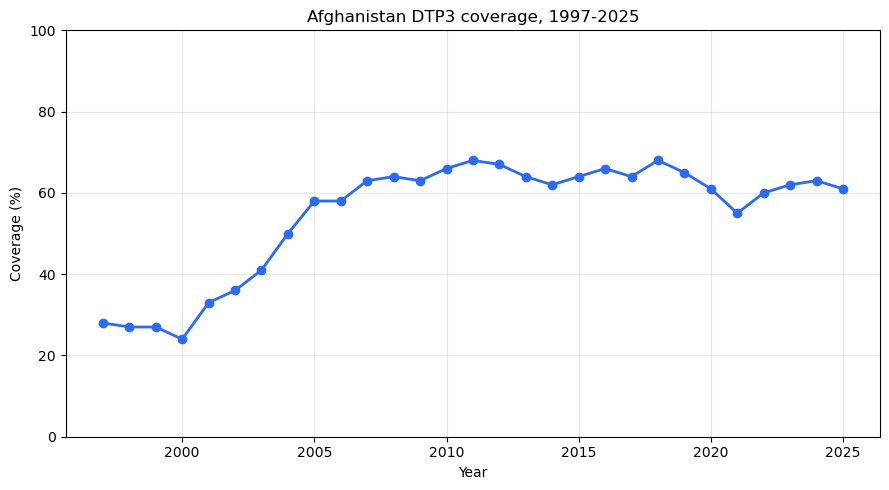

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
afg = df.query("Country == 'Afghanistan' and Vaccine == 'DTP3'").sort_values("Year")
ax.plot(afg["Year"], afg["WUENIC"], marker="o", linewidth=2, color="#2c6bed")
ax.set_title("Afghanistan DTP3 coverage, 1997-2025")
ax.set_xlabel("Year")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Saving a figure

In [32]:
fig.savefig('afg_dtp3.png', dpi=200, bbox_inches='tight')

## Step 4.2: Small multiples--one plot per antigen

plt.subplots returns a 2D array of axes. Iterate over them in a flat loop with .ravel() so the indexing stays simple.

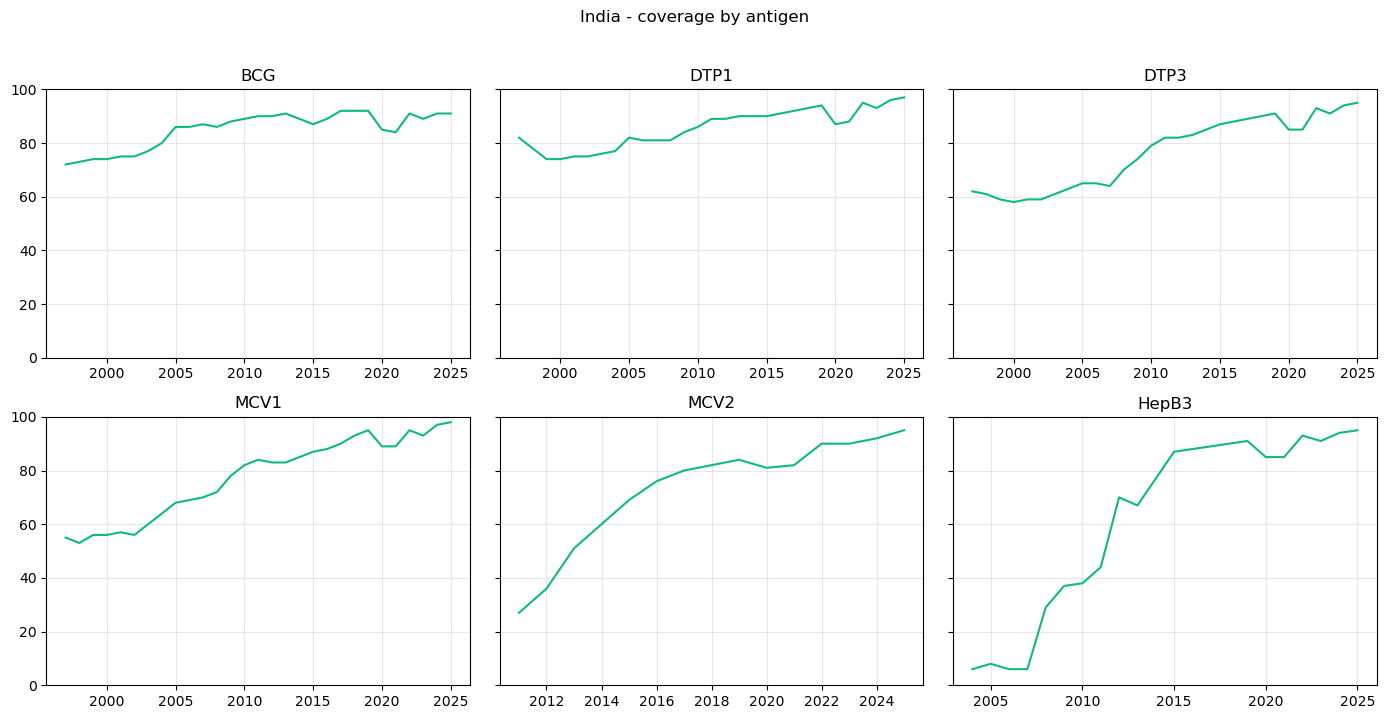

In [33]:
vaccines_to_plot = ["BCG", "DTP1", "DTP3", "MCV1", "MCV2", "HepB3"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, v in zip(axes.ravel(), vaccines_to_plot):
    sub = df.query("Country == 'India' and Vaccine == @v").sort_values("Year")
    ax.plot(sub["Year"], sub["WUENIC"], color="#10b981")
    ax.set_title(v)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)
fig.suptitle("India - coverage by antigen", y=1.02)
plt.tight_layout()
plt.show()

## Step 4.3: Annotated chart of largest COVID drops

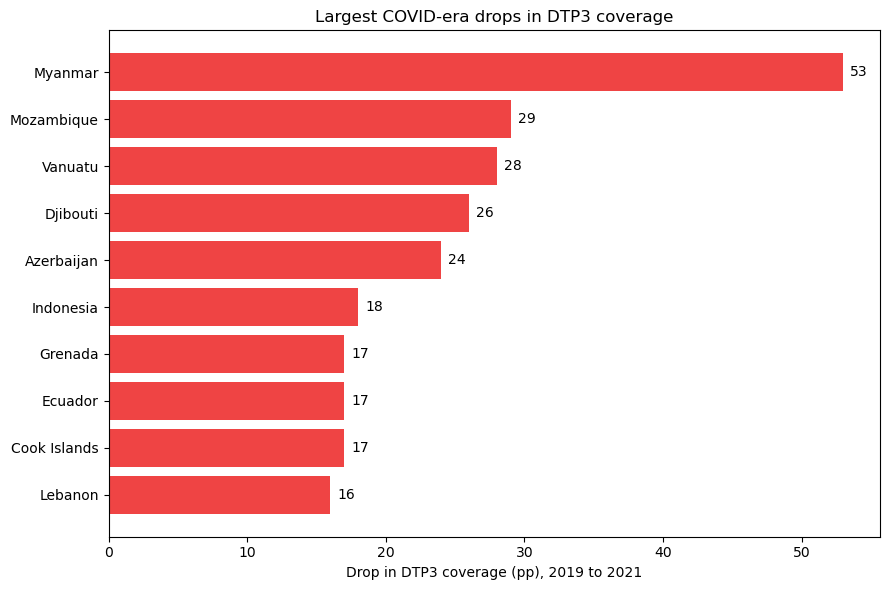

In [34]:
drops = (pivot[2019] - pivot[2021]).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(drops.index[::-1], drops.values[::-1], color="#ef4444")
ax.set_xlabel("Drop in DTP3 coverage (pp), 2019 to 2021")
ax.set_title("Largest COVID-era drops in DTP3 coverage")
for i, v in enumerate(drops.values[::-1]):
    ax.text(v + 0.5, i, f"{v:.0f}", va="center")
plt.tight_layout()
plt.show()

# 5. Seaborn--statistical plots in fewer lines

Seaborn wraps Matplotlib for the common statistical chart types. The big idea: pass it a long-form DataFrame and tell it which columns map to which visual roles. The figure is built for you.

## Step 5.1: Distribution of coverage by antigen

C:\Users\kellyja\AppData\Local\Temp\ipykernel_28360\1868879022.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="Vaccine", y="WUENIC",


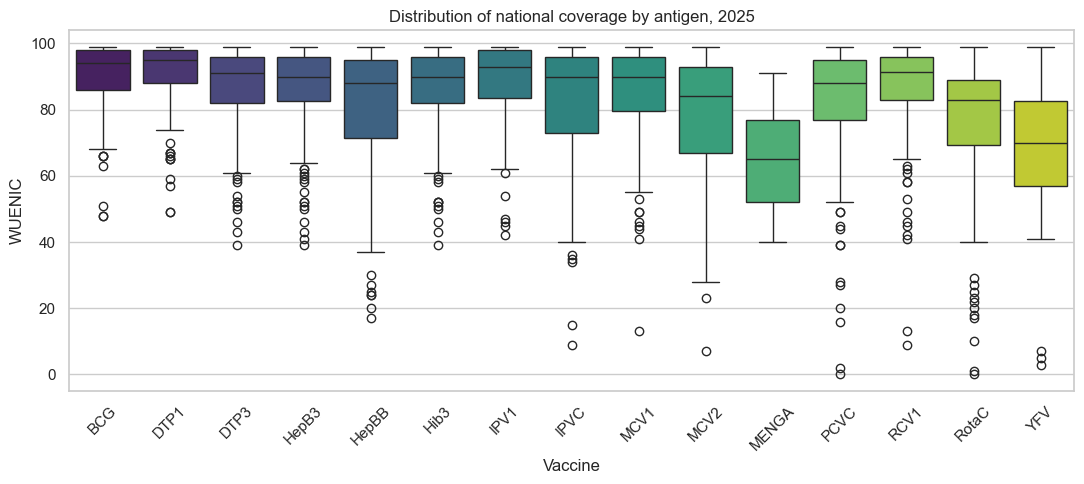

In [35]:
import seaborn as sns
sns.set_theme(style="whitegrid")

subset = df[df["Year"] == 2025]
plt.figure(figsize=(11, 5))
sns.boxplot(data=subset, x="Vaccine", y="WUENIC",
            order=sorted(subset["Vaccine"].unique()),
            palette="viridis")
plt.xticks(rotation=45)
plt.title("Distribution of national coverage by antigen, 2025")
plt.tight_layout()
plt.show()

C:\Users\kellyja\AppData\Local\Temp\ipykernel_28360\3286728469.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x="Vaccine", y="WUENIC",


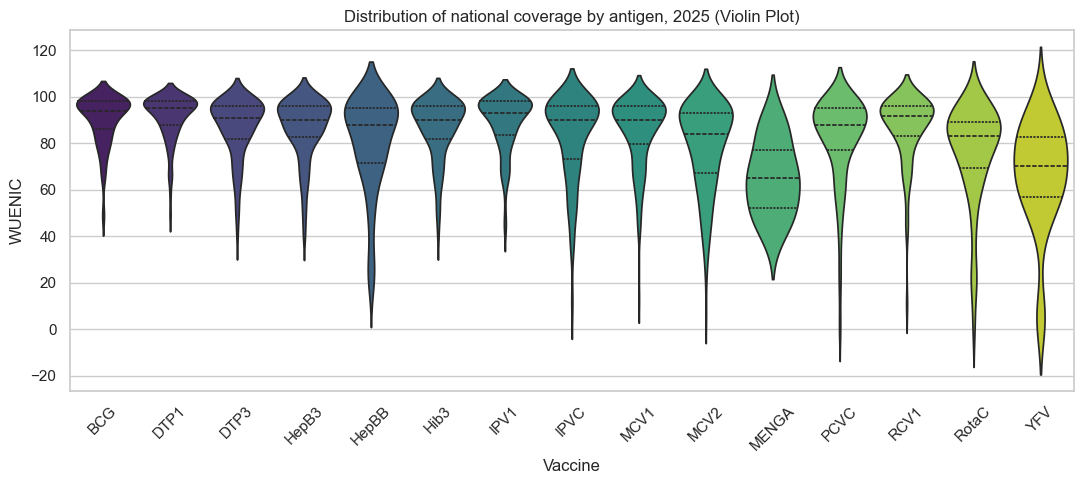

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
subset = df[df["Year"] == 2025]

plt.figure(figsize=(11, 5))
sns.violinplot(data=subset, x="Vaccine", y="WUENIC",
                order=sorted(subset["Vaccine"].unique()),
                palette="viridis", inner="quartile")
plt.xticks(rotation=45)
plt.title("Distribution of national coverage by antigen, 2025 (Violin Plot)")
plt.tight_layout()
plt.show()

## Step 5.2: Heatmap of correlations between antigens

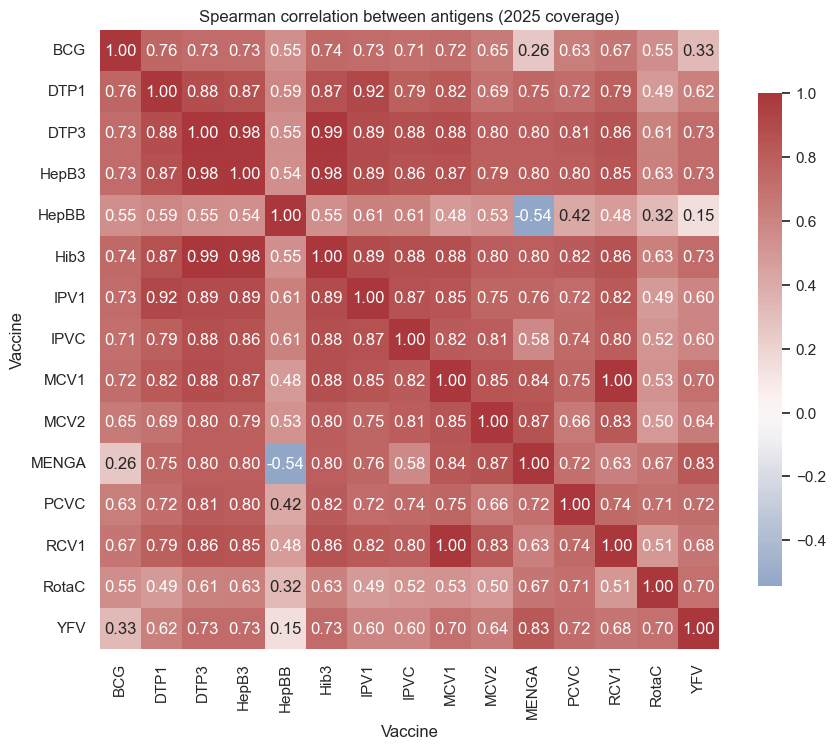

In [37]:
corr = w25.corr(method="spearman")
plt.figure(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, cbar_kws={"shrink": 0.7})
plt.title("Spearman correlation between antigens (2025 coverage)")
plt.tight_layout()
plt.show()

## Step 5.3: Regression plot

Plot the relationship between DTP3 and MCV1 with a fitted regression line and a 95% CI band, in one line:

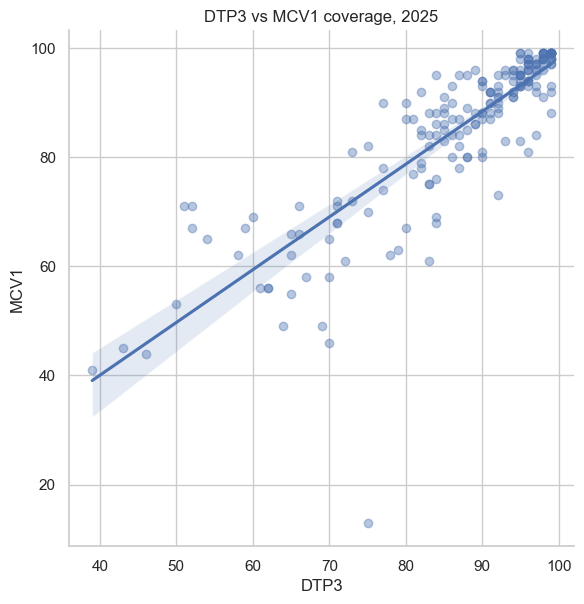

In [38]:
sns.lmplot(data=w25, x="DTP3", y="MCV1", height=6, scatter_kws={"alpha": 0.4})
plt.title("DTP3 vs MCV1 coverage, 2025")
plt.show()

In [39]:
import statsmodels.api as smf

X = sm.add_constant(w25["DTP3"])
model = sm.OLS(w25["MCV1"], X, missing="drop").fit()
w25["predicted_MCV1"] = model.predict(X)
w25["residual"] = w25["MCV1"] - w25["predicted_MCV1"]

# biggest underperformers relative to DTP3
print(w25.nsmallest(5, "residual")[["Country", "DTP3", "MCV1", "residual"]])

# biggest overperformers relative to DTP3
print(w25.nlargest(5, "residual")[["Country", "DTP3", "MCV1", "residual"]])

NameError: name 'sm' is not defined

In [ ]:
df_dtp3 = df.query("Vaccine == 'DTP3'").copy()
df_dtp3["decade"] = (df_dtp3["Year"] // 10) * 10

g = sns.FacetGrid(df_dtp3, col="decade", height=3.5, aspect=1.1, sharey=True)
g.map_dataframe(sns.histplot, x="WUENIC", bins=20, color="#2c6bed")
g.set_axis_labels("DTP3 coverage (%)", "Count")
g.set_titles("{col_name}s")
plt.tight_layout()
plt.show()

# 6. Plotly--interactive visualizations and dashboards

Plotly is the right tool when you want to hand a chart to someone else and let them zoom, hover, filter, and toggle traces. The accompanying wuenic_explorer.html file uses Plotly under the hood. Here we cover the building blocks.

## Step 6.1: A single interactive line chart

In [ ]:
import plotly.express as px

countries = ["Pakistan", "India", "Nigeria", "Ethiopia", "Democratic Republic of the Congo", "Niger", "Somalia"]
sub = df[(df["Country"].isin(countries)) & (df["Vaccine"] == "DTP3")]
fig = px.line(sub, x="Year", y="WUENIC", color="Country",
              markers=True, title="DTP3 coverage, selected countries")
fig.update_yaxes(range=[0, 100])
fig.show()

## Step 6.2: World choropleth

ISO codes make this almost free. Pass the three-letter codes as locations and Plotly handles the geometry.

In [ ]:
map_df = df.query("Vaccine == 'MCV1' and Year == 2025")
fig = px.choropleth(map_df,
                    locations="ISOCountryCode",
                    color="WUENIC",
                    hover_name="Country",
                    color_continuous_scale="RdYlGn",
                    range_color=(0, 100),
                    title="Measles (MCV1) coverage, 2025")
fig.update_geos(projection_type="natural earth")
fig.show()

## Step 6.3: Animated bubble chart over time

Plotly Express's animation_frame argument turns any static plot into an animated one. Watch DTP1 vs DTP3 coverage move over 25 years:

In [ ]:
anim = df.query("Vaccine in ['DTP1', 'DTP3']").pivot_table(
    index=["Country", "Year"], columns="Vaccine", values="WUENIC"
).reset_index().dropna()

fig = px.scatter(anim, x="DTP1", y="DTP3", animation_frame="Year",
                 hover_name="Country", range_x=[0, 100], range_y=[0, 100],
                 title="DTP1 vs DTP3 over time")
# Add the y=x line: full coverage of dose 1 should also reach dose 3
fig.add_shape(type="line", x0=0, y0=0, x1=100, y1=100,
              line=dict(color="grey", dash="dash"))
fig.show()

## Step 6.4: Saving and embedding

Plotly figures save to standalone HTML files that work without a server:

In [ ]:
fig.write_html("my_chart.html", include_plotlyjs="cdn")

# 7. statsmodels--regression with proper inference

scikit-learn is great for prediction. statsmodels is the right tool when you want p-values, confidence intervals, and diagnostic plots. The textbook regression workflow lives here.

## Step 7.1: Linear regression with a formula API

Ask: holding the year constant, is GradeOfConfidence (a flag for measurement quality) associated with reported coverage?

In [ ]:
import statsmodels.formula.api as smf

m = smf.ols("WUENIC ~ Year + C(GradeOfConfidence) + C(Vaccine)",
            data=df).fit()
print(m.summary())

## Step 7.2: Time-series view--fit a trend for one country-antigen

In [ ]:
one = df.query("Country == 'India' and Vaccine == 'DTP3'").sort_values("Year")
m = smf.ols("WUENIC ~ Year", data=one).fit()
print(f"Slope: {m.params['Year']:.3f} pp/year")
print(f"95% CI: {m.conf_int().loc['Year'].values}")
print(f"R-squared: {m.rsquared:.3f}")

## Step 7.3: Fixed-effects panel regression

Each country has its own baseline. To estimate a 'within-country' time trend, include a fixed effect for each country. The C(Country) term absorbs all time-invariant country differences.

In [ ]:
fe = smf.ols("WUENIC ~ Year + C(Country) + C(Vaccine)",
             data=df).fit()
print(f"Year coefficient: {fe.params['Year']:.3f}")
print(f"   (interpreted as 'within-country, within-vaccine' annual change)")

## Step 7.4: Logistic regression--predict 'below 90'

In [ ]:
df["below_90"] = (df["WUENIC"] < 90).astype(int)

logit = smf.logit("below_90 ~ Year + C(Vaccine) + np.log1p(SurvivingInfantsUNPD)",
                  data=df).fit(disp=False)
print(logit.summary())

## Step 7.5: ARIMA forecast for a single country

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
 
india_dtp3 = (df.query("Country == 'Democratic Republic of the Congo' and Vaccine == 'DTP3'")
                .sort_values("Year"))

# Build a proper annual period index from the Year column
india_dtp3 = india_dtp3.set_index(
    pd.PeriodIndex(india_dtp3["Year"], freq="Y")
)["WUENIC"]

model = ARIMA(india_dtp3, order=(1, 1, 1)).fit()
forecast = model.get_forecast(steps=5)
print(forecast.summary_frame())

On overinterpreting WUENIC trends
The data is annual and the time series per country is short (28 points). ARIMA-style models give you a point forecast and an interval, but treat them as descriptive rather than authoritative. A model that incorporates campaign data and stock-out flags will always be better.

# 8. scikit-learn--clustering and prediction

Two flavors of machine learning are well-suited to WUENIC: unsupervised clustering to find countries with similar coverage profiles, and supervised regression to predict next year's coverage from past coverage.

## Step 8.1: Cluster countries by coverage profile

Each country has a vector of 16 antigen coverage values for 2024. K-means groups countries whose vectors are similar. First standardise the inputs so that no single antigen dominates.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# country x vaccine matrix for 2025
X = df[df["Year"] == 2025].pivot(index="Country", columns="Vaccine", values="WUENIC")
X = X.dropna(axis=1, thresh=int(0.8 * len(X)))   #drop antigens with too many NAs
X = X.dropna()                                   #drop countries with any missing antigens
print(X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pick k with the elbow / silhouette method (skipped here; let's say k=4)
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_scaled)
clusters = pd.Series(km.labels_, index=X.index, name="cluster")
clusters.value_counts()

In [ ]:
pca = PCA(n_components=2).fit(X_scaled)
coords = pca.transform(X_scaled)
plot_df = pd.DataFrame({"PC1": coords[:, 0], "PC2": coords[:, 1],
                        "cluster": clusters.values, "Country": X.index})

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="tab10")
plt.title("2025 coverage profile - PCA + KMeans")
plt.show()

## Step 8.2: Predict next-year coverage

For every country-antigen series, use the past 5 years to predict the next. This is the simplest kind of time-series regression and a good teaching example.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Build features: 5 lagged values predict the current value

def lag_features(group, n=5):
    g = group.sort_values("Year").reset_index(drop=True)
    for k in range(1, n + 1):
        g[f"lag_{k}"] = g["WUENIC"].shift(k)
    return g

feat = (df.groupby(["Country", "Vaccine"], group_keys=False)
        .apply(lag_features)
        .dropna())

y = feat["WUENIC"]
X = feat[[f"lag_{k}" for k in range(1, 6)]]

# Time-aware split: train on <= 2019, test on >=2020
mask_train = feat["Year"] <= 2019
mask_test = feat["Year"] >= 2020

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X[mask_train], y[mask_train])
pred = rf.predict(X[mask_test])

print(f"MAE: {mean_absolute_error(y[mask_test], pred):.2f} pp")
print(f"R-squared: {r2_score(y[mask_test], pred):.3f}")
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

## Step 8.3: Pipelines and cross-validation

Wrap preprocessing and model fitting in a Pipeline so they cross-validate together and never leak data:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])
cv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(pipe, X, y, cv=cv, scoring="neg_mean_absolute_error")
print(f"CV MAE: {-scores.mean():.2f} +/- {scores.std():.2f}")

# 9. SymPy--symbolic math for derivations

SymPy is the odd one out in this list: it does symbolic algebra rather than numeric computation. The use case in a coverage analysis is to derive a formula once, then use it in NumPy at scale. We will derive two things: the coverage formula and an exponential model fit.

## Step 9.1: The coverage identity

Coverage is doses divided by target. Let's define it symbolically and rearrange:

In [ ]:
import sympy as sp

doses, target, coverage = sp.symbols("doses target coverage", positive=True)
formula = sp.Eq(coverage, doses / target)
print(formula)

# Solve for doses given coverage and target
solved = sp.solve(formula, doses)[0]
print("doses =", solved)
# Solve for target given coverage and doses
solved_target = sp.solve(formula, target)[0]
print("target =", solved_target)

## Step 9.2: Exponential growth model

Suppose you model coverage as approaching 100% according to C(t) = 100 - a·exp(-k·t). Use SymPy to derive the time-to-90% as a function of a and k, then evaluate it numerically.

In [ ]:
t, a, k = sp.symbols("t a k", positive=True)
C = 100 - a * sp.exp(-k * t)

# Time when C(t) = 90
t_90 = sp.solve(sp.Eq(C, 90), t)[0]
print("t at 90% coverage =", t_90)

# Convert to a fast NumPy function
t_90_fn = sp.lambdify((a, k), t_90, modules="numpy")
print("Example: a=50, k=0.1 -> t =", t_90_fn(50, 0.1))

## Step 9.3: Derivative of the trend

If coverage follows C(t), the instantaneous rate of change is C'(t). SymPy differentiates symbolically:

In [ ]:
dC_dt = sp.diff(C, t)
print("dC/dt =", sp.simplify(dC_dt))
# Convert to NumPy for plotting against actual data
slope_fn = sp.lambdify((t, a, k), dC_dt, modules="numpy")

# Putting it together--a mini end-to-end analysis

Here is the workflow for one well-defined question: which countries are most off-track for DTP3 in 2024, and what do their recent trajectories look like? The point of this section is to show you that what we have learned is enough to answer a real-world question in 30 lines of code.

In [ ]:
# 1) Load and filter
df = pd.read_parquet("wuenic_clean.parquet")
dtp3 = df[df["Vaccine"] == "DTP3"].copy()
 
# 2) Identify off-track countries (2025 coverage < 80)
off = (dtp3[dtp3["Year"] == 2025]
         .query("WUENIC < 80")
         .sort_values("WUENIC")
         .head(15)["Country"]
         .tolist())
print("Off-track:", off)
 
# 3) Compute trend slope (statsmodels) for each
slopes = {}
for c in off:
    series = dtp3.query("Country == @c and Year >= 2015").sort_values("Year")
    m = smf.ols("WUENIC ~ Year", data=series).fit()
    slopes[c] = m.params["Year"]
slopes = pd.Series(slopes).sort_values()
print(slopes)
 
# 4) Visualize trajectories together (Plotly)
fig = px.line(dtp3[dtp3["Country"].isin(off) & (dtp3["Year"] >= 2015)],
              x="Year", y="WUENIC", color="Country", markers=True,
              title="DTP3 trajectories — off-track countries (2015-2025)")
fig.update_yaxes(range=[0, 100])
fig.write_html("off_track.html")
 
# 5) Summary table
summary = pd.DataFrame({
    "coverage_2025": dtp3[dtp3["Year"] == 2025].set_index("Country")["WUENIC"].reindex(off),
    "slope_2015_2025_pp_per_yr": slopes.reindex(off).round(2),
})
summary["risk"] = np.where(
    (summary["coverage_2025"] < 50) | (summary["slope_2015_2025_pp_per_yr"] < 0),
    "high", "moderate")
print(summary)

## WUENIC and Coverage Stuff

The WHO measures dropout rates across multi-dose series or between two different scheduled antigens.

#### 1. Multi-Dose Series Dropout Rate (e.g. DTP1 to DTP3)

This measures children who started a series but did not complete it.

$\text{Dropout Rate}=\dfrac{\text{Number receiving dose 1}-\text{Number receiving dose 3}}{\text{Number receiving dose 1}}\times100%$

#### 2. Cross-Antigen Dropout Rate (e.g., DTP1 to MCV1)

This measures children who accessed early infant vaccines but missed later ones, like the first dose of the Measles-Containing Vaccine (MCV1).

$\text{Dropout Rate}=\dfrac{\text{Number receiving DTP1}-\text{Number receiving MCV1}}{\text{Number receiving DTP1}}\times100%$

#### WHO Performance Benchmarks

The WHO categorizes immunization program health by cross-referencing **DTP3 Coverage** with the **DTP1-to-DTP3 Dropout Rate** to sort health systems into four categories:

- **High Coverage & Low Dropout ($<$10%):** Indicates a high-performing system with strong community access to demand.
- **High Coverage & High Dropout ($>=$10%):** Indicates good initial access, but the system struggles to retain families for follow-up doses.
- **Low Coverage & Low Dropout ($<$10%):** Signfies that while the program is efficient at completing schedules for those it reaches, overall access is severely limited.
- **Low Coverage & High Dropout($>=$10%):** Indicates a critical program failure, suffering from both poor initial access and a failure to retain patients.

In [ ]:
# Reshape to wide: one row per Country-Year, one column per antigen
wide = df.pivot_table(index=['Country', 'Year'], columns='Vaccine', values='WUENIC')

# Two cascade-leak metrics, computed at the country-year grain
wide['multi_dose_dropout']    = (wide['DTP1'] - wide['DTP3']) / wide['DTP1']
wide['cross_antigen_dropout'] = (wide['DTP1'] - wide['MCV1']) / wide['DTP1']

In [ ]:
# bring surviving-infants back in to filter out tiny denominators
surv = df[df['Vaccine']=='DTP1'][['Country','Year']].copy()  # placeholder if you have the column
# ...or if SurvivingInfantsUNPD is in your wide table, just:
mask = (
    (wide['DTP1'] > 80) &
    (wide['multi_dose_dropout'] > 0.10) |
    (wide['cross_antigen_dropout'] > 0.10) &
    (wide['SurvivingInfantsUNPD'] > 100_000)   # only substantial cohorts
)

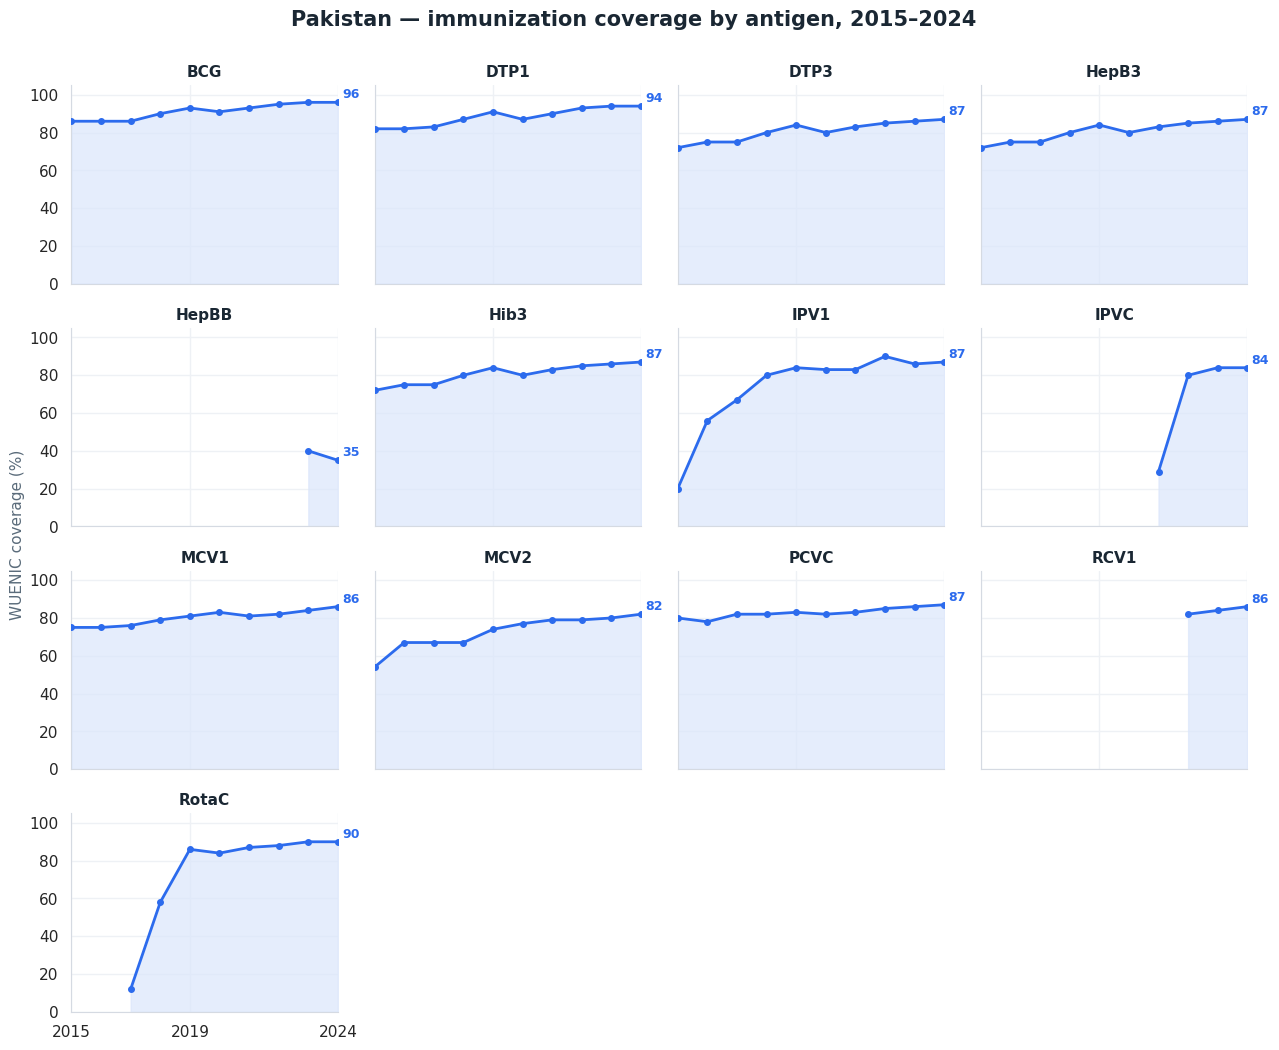

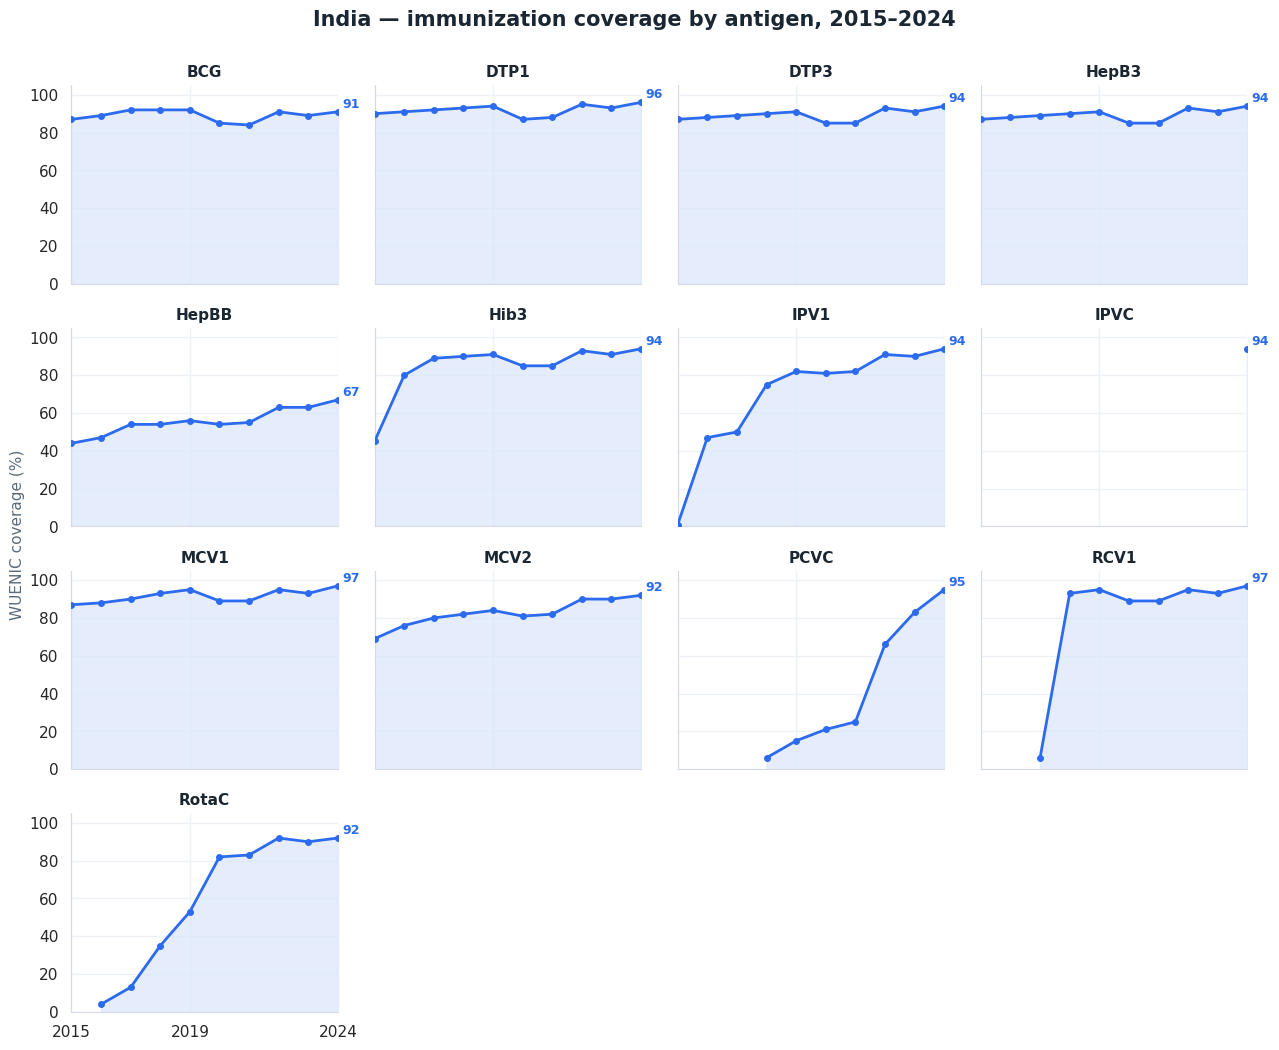

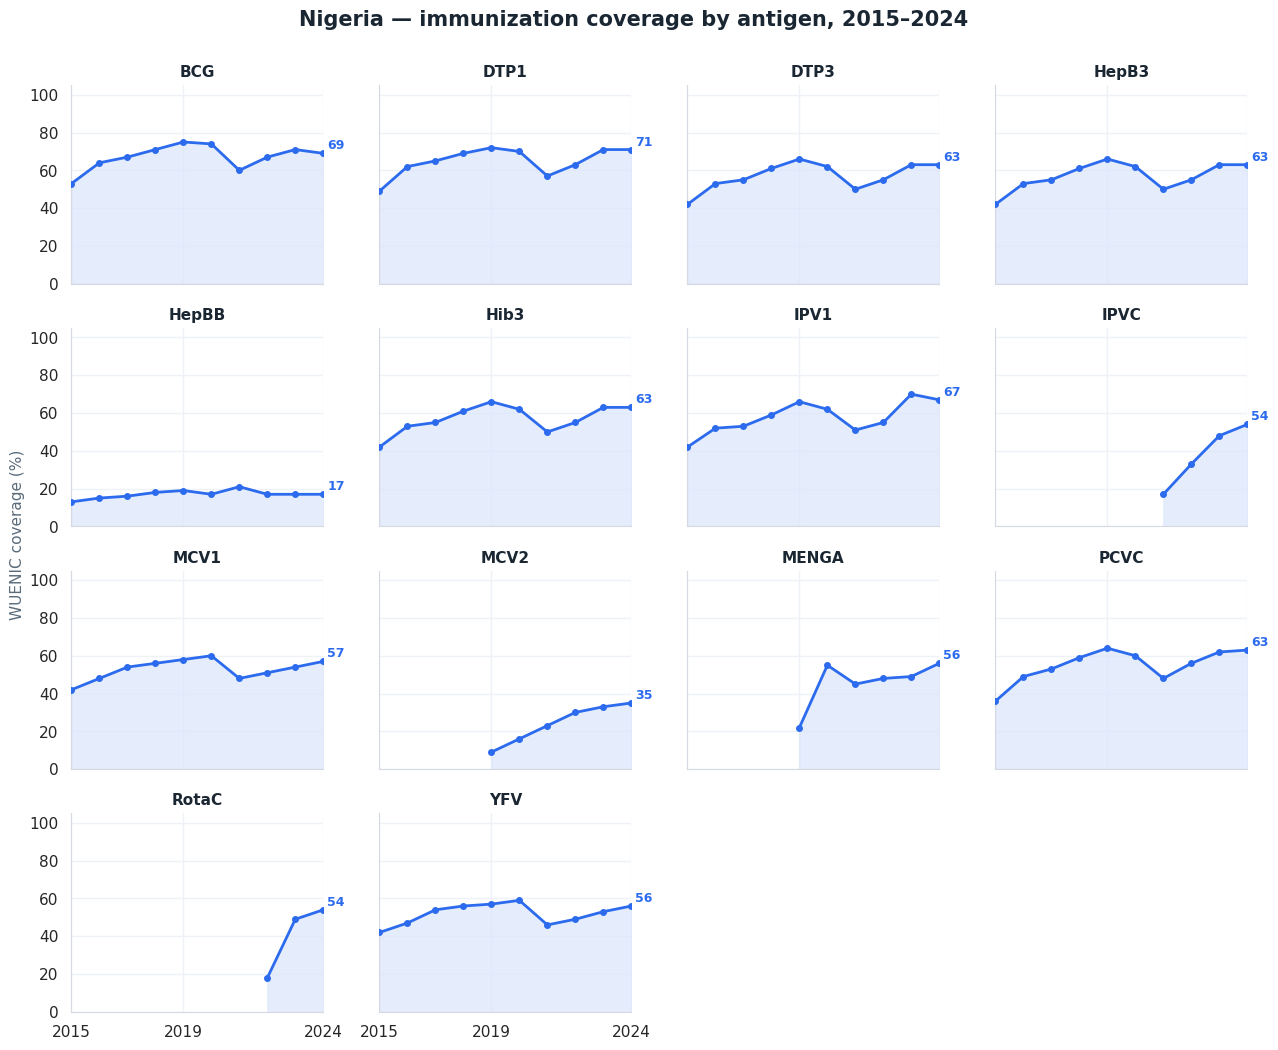

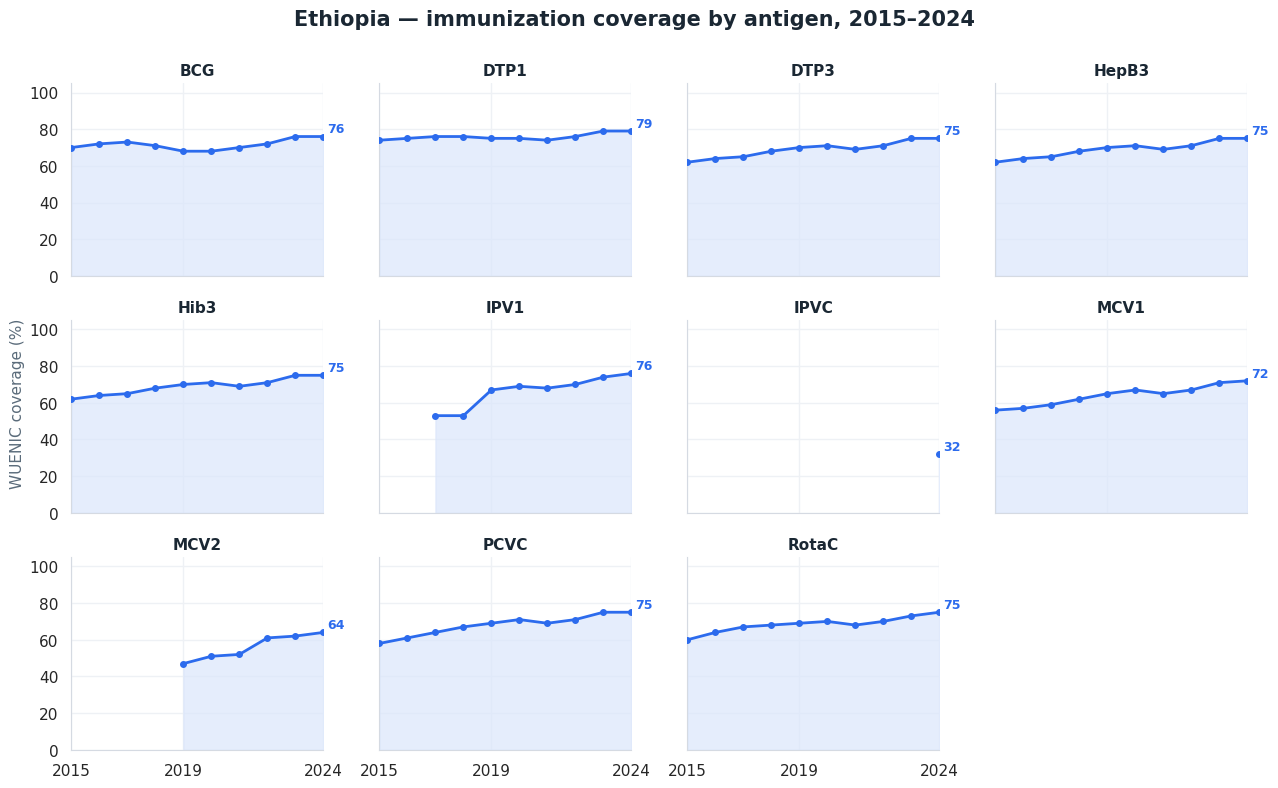

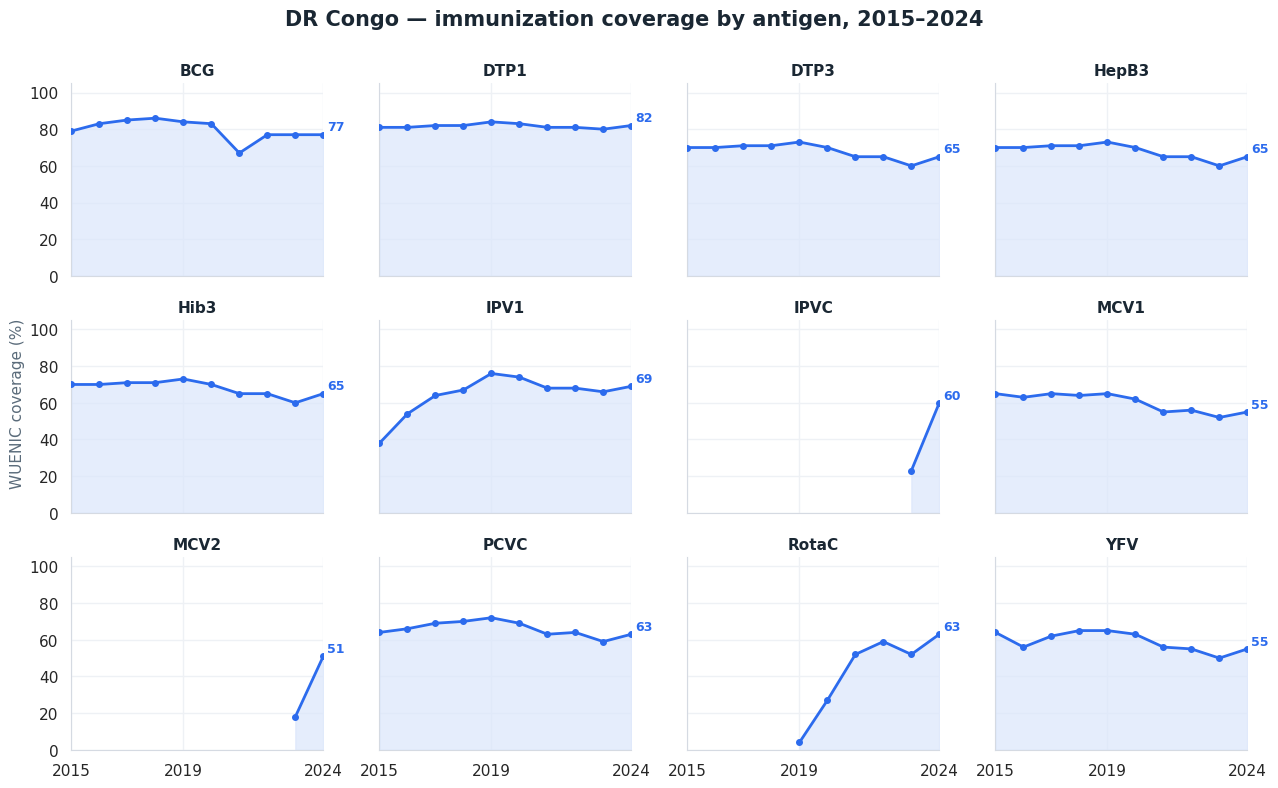

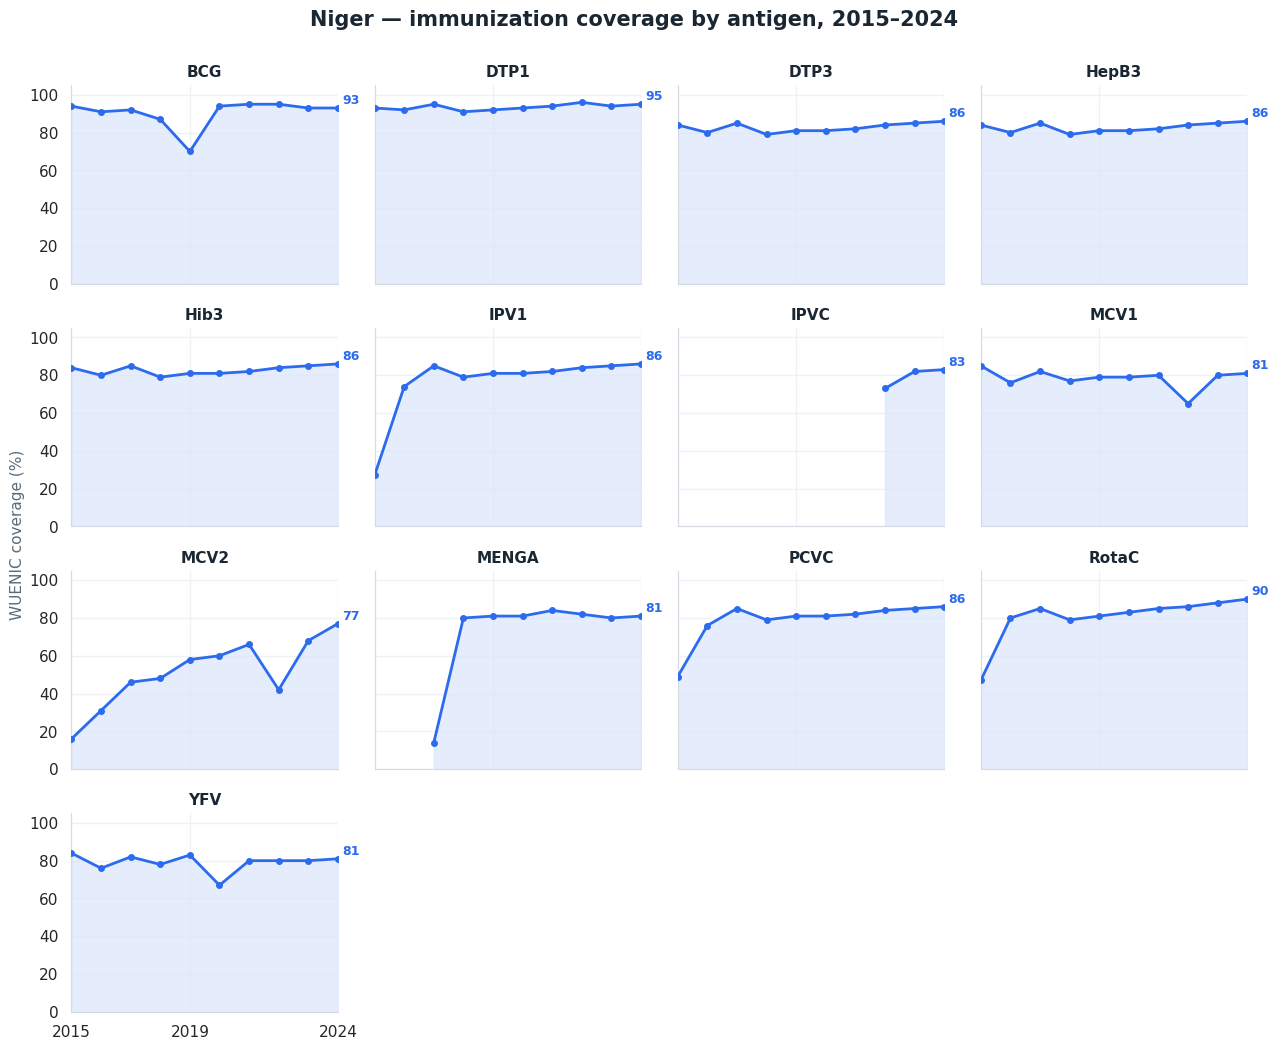

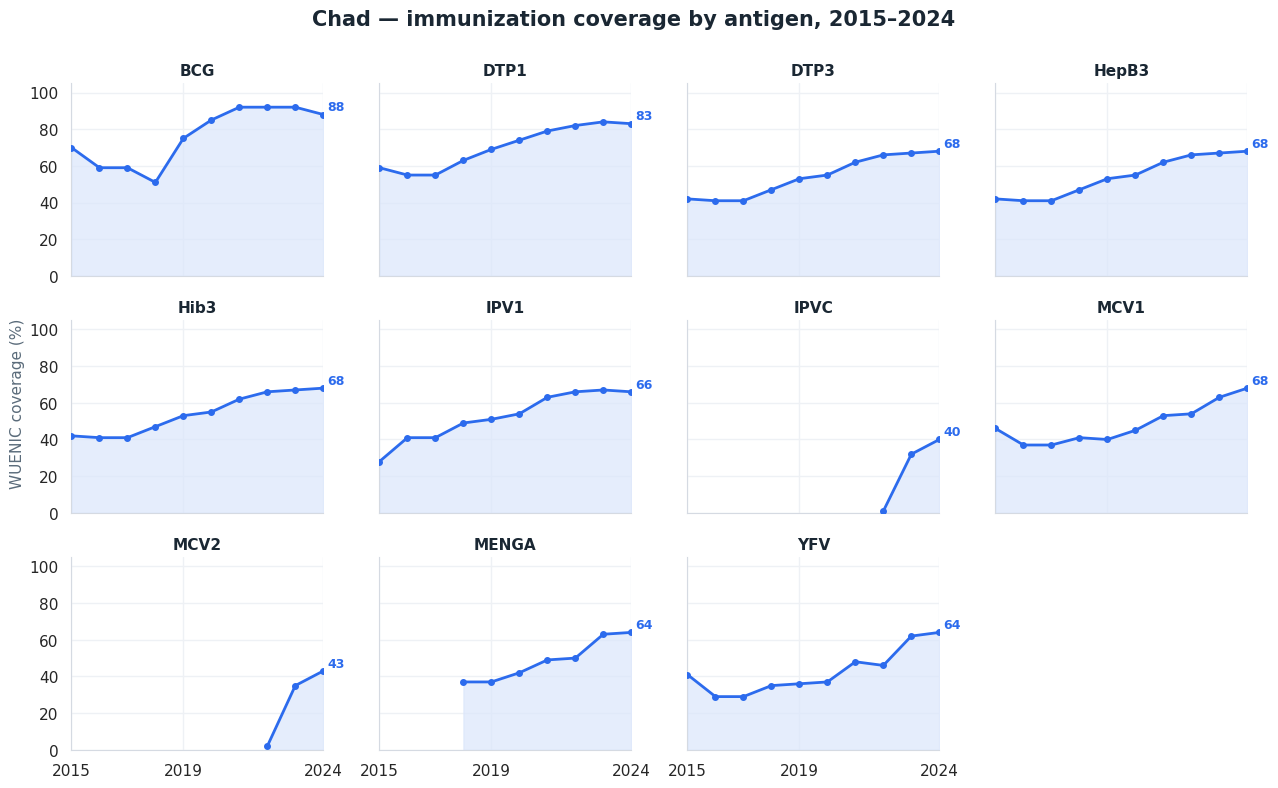

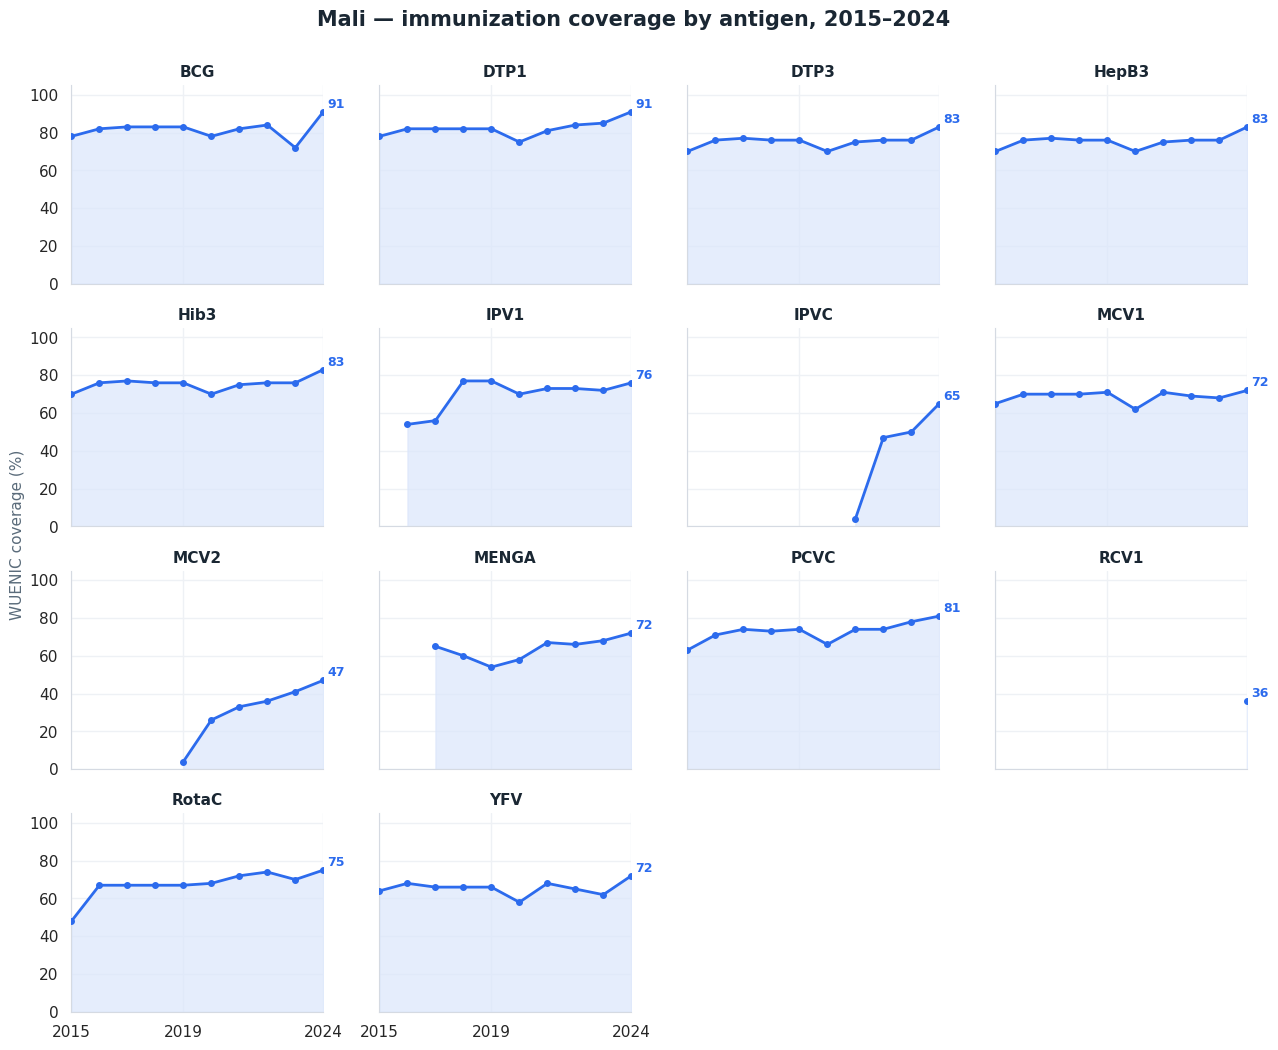

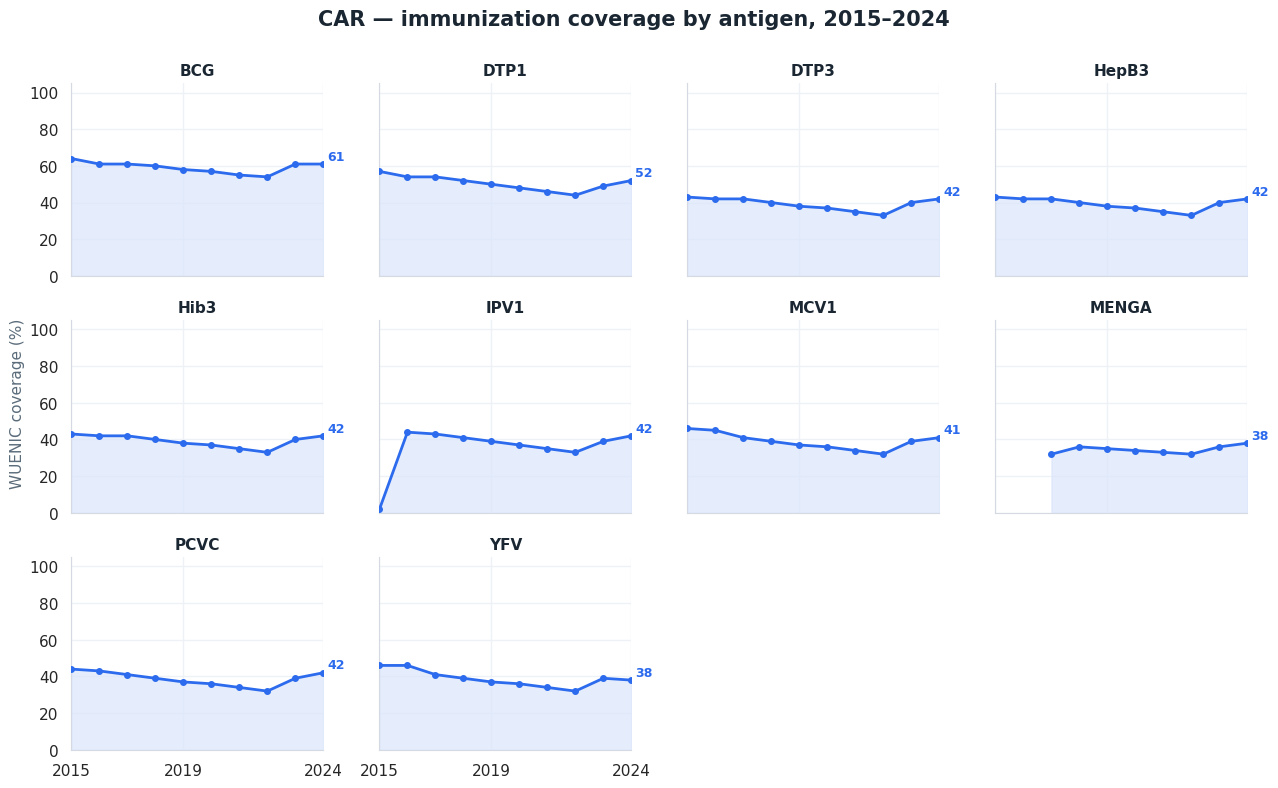

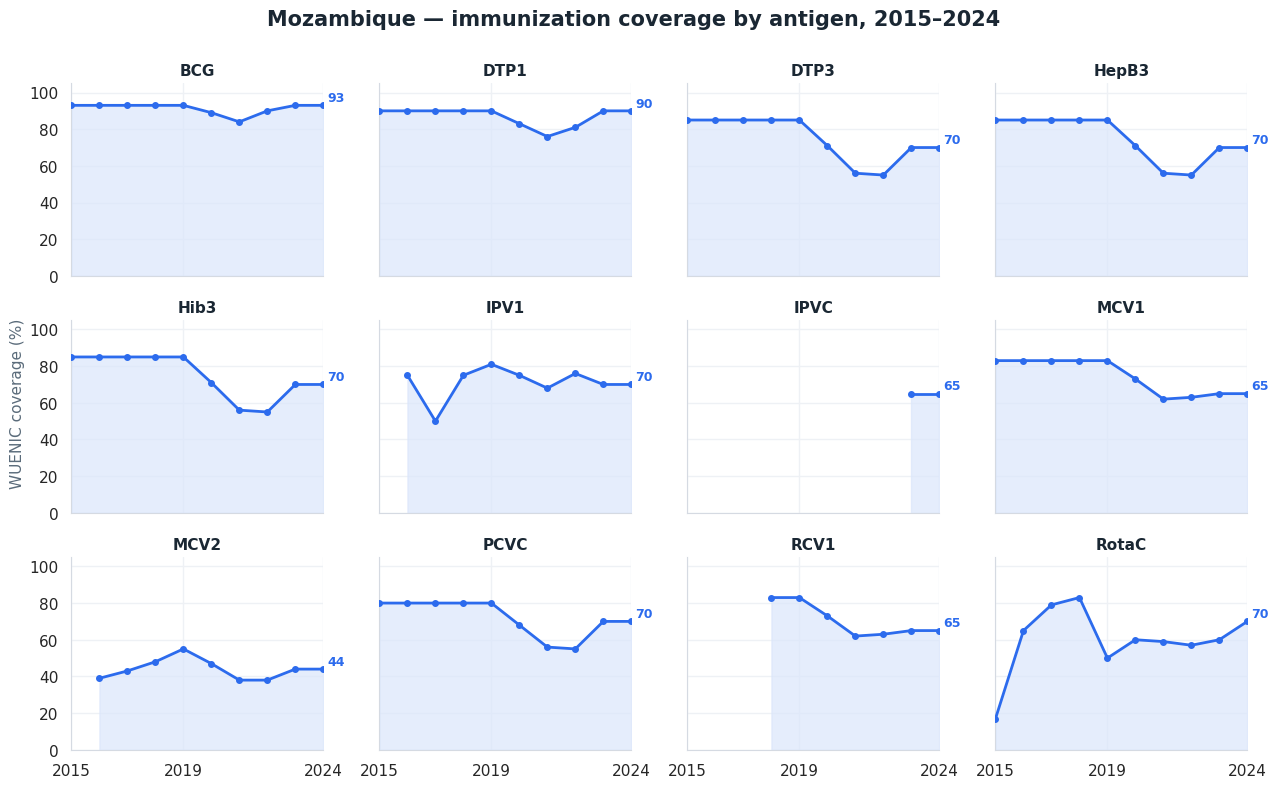

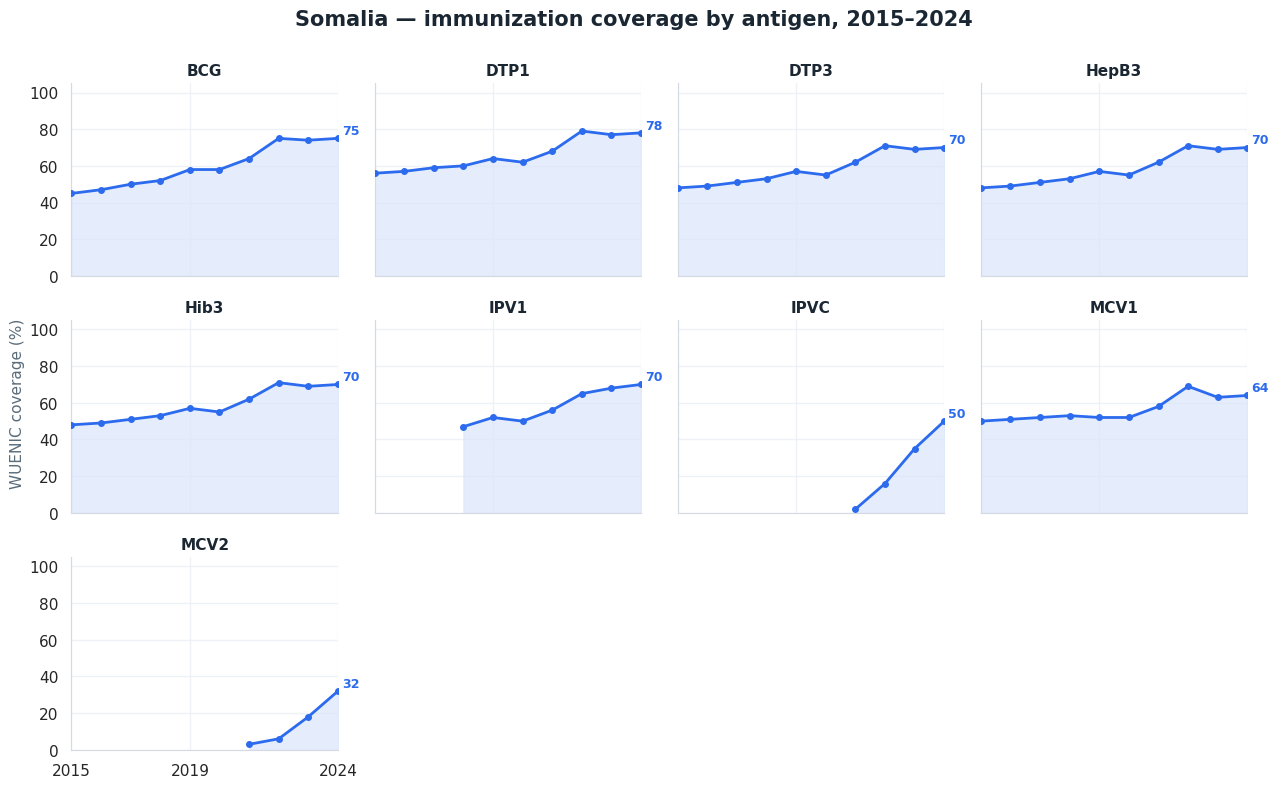

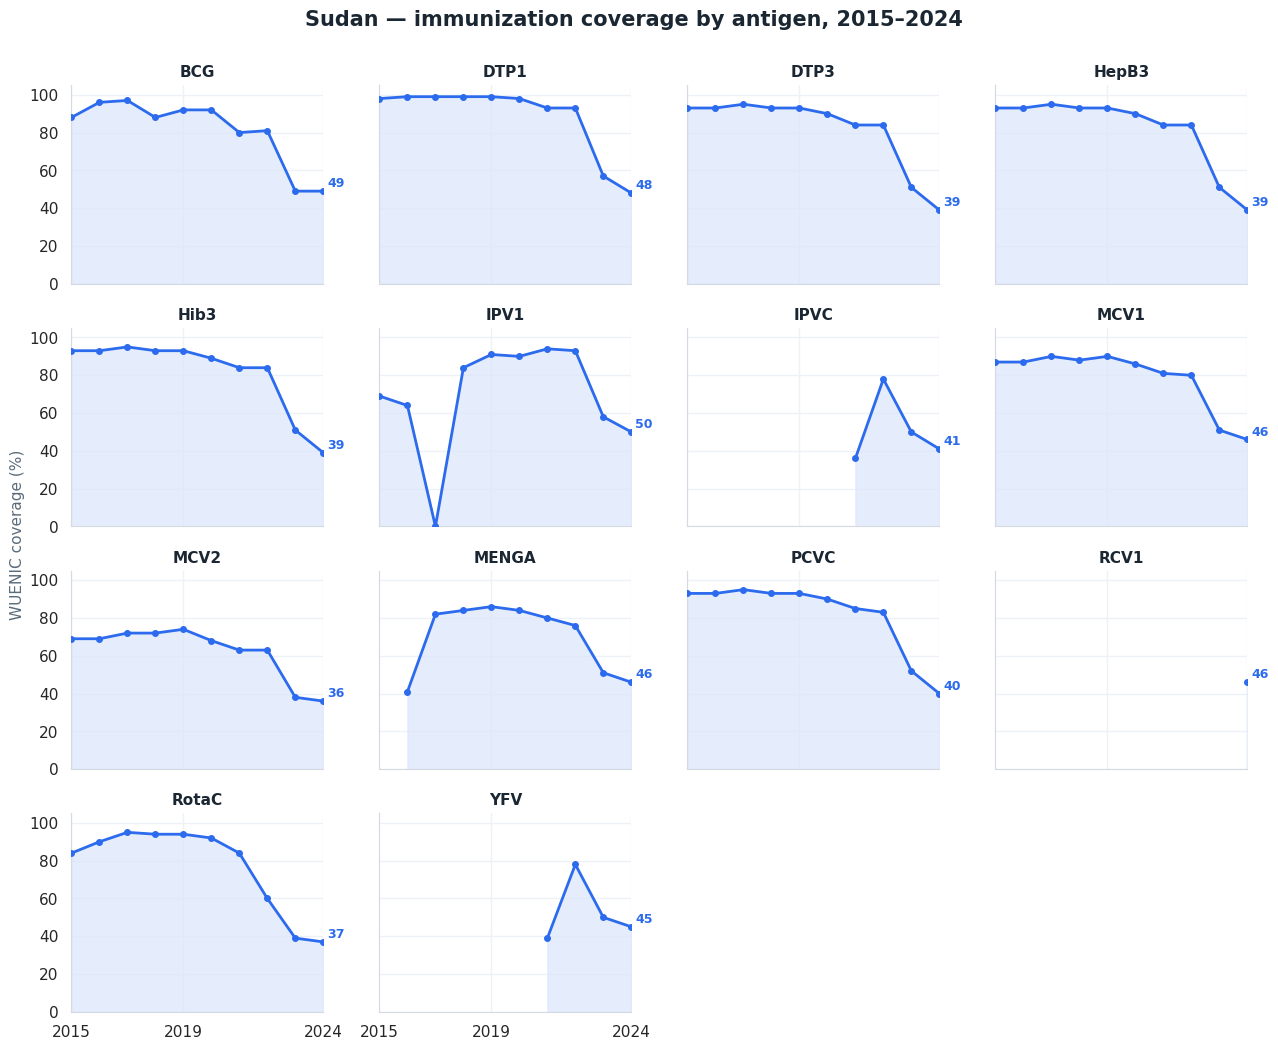

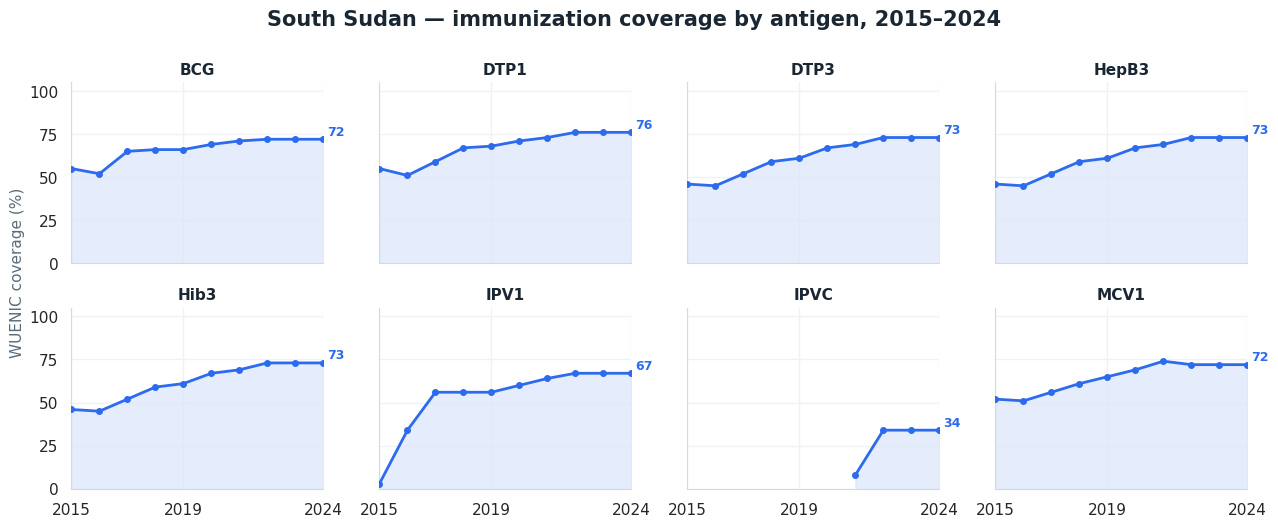

Saved 13 antigen panels to C:\Users\kellyja\Documents\Projects\Ubiquitous\Projects\WUENIC 2026\charts


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- shared styling (run once) ----------
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.edgecolor': '#d5dae2', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#eef1f5', 'grid.linewidth': 1.0,
    'axes.spines.top': False, 'axes.spines.right': False,
})
ACCENT, FILL = '#2c6bed', '#dbe6fb'
START, END = 2015, 2024                      # the 10-year window
OUT = Path('charts'); OUT.mkdir(exist_ok=True)

# user shorthand -> exact WUENIC country name
COUNTRIES = {
    'Pakistan': 'Pakistan', 'India': 'India', 'Nigeria': 'Nigeria',
    'Ethiopia': 'Ethiopia', 'DR Congo': 'Democratic Republic of the Congo',
    'Niger': 'Niger', 'Chad': 'Chad', 'Mali': 'Mali',
    'CAR': 'Central African Republic', 'Mozambique': 'Mozambique',
    'Somalia': 'Somalia', 'Sudan': 'Sudan', 'South Sudan': 'South Sudan',
}

def plot_country_antigens(country_full, country_label, start=START, end=END):
    sub = df[(df['Country'] == country_full) & (df['Year'].between(start, end))]
    antigens = sorted(sub['Vaccine'].unique())
    n = len(antigens)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 2.6 * nrows),
                             sharex=True, sharey=True)
    axes = np.array(axes).ravel()

    for ax, ant in zip(axes, antigens):
        s = sub[sub['Vaccine'] == ant].sort_values('Year')
        ax.fill_between(s['Year'], s['WUENIC'], color=FILL, alpha=0.7, zorder=1)
        ax.plot(s['Year'], s['WUENIC'], color=ACCENT, lw=2, zorder=3)
        ax.plot(s['Year'], s['WUENIC'], 'o', color=ACCENT, ms=4, zorder=4)
        if len(s):
            last = s.iloc[-1]
            ax.annotate(f"{last['WUENIC']:.0f}", xy=(last['Year'], last['WUENIC']),
                        xytext=(3, 3), textcoords='offset points',
                        fontsize=9, fontweight='bold', color=ACCENT)
        ax.set_title(ant, fontsize=11, fontweight='bold', color='#1a2733')
        ax.set_ylim(0, 105); ax.set_xlim(start, end)
        ax.set_xticks([start, (start + end) // 2, end])

    for ax in axes[n:]:              # hide unused cells
        ax.set_visible(False)

    fig.suptitle(f"{country_label} — immunization coverage by antigen, {start}–{end}",
                 fontsize=15, fontweight='bold', color='#1a2733', y=1.005)
    fig.supylabel('WUENIC coverage (%)', fontsize=11, color='#5a6b7a')
    fig.tight_layout()
    return fig

for label, full in COUNTRIES.items():
    fig = plot_country_antigens(full, label)
    fname = OUT / f"antigens_{label.replace(' ', '_')}.png"
    fig.savefig(fname, dpi=200, bbox_inches='tight')   # dpi=200 = crisp in Word
    plt.show()
    plt.close(fig)
print(f"Saved {len(COUNTRIES)} antigen panels to {OUT.resolve()}")

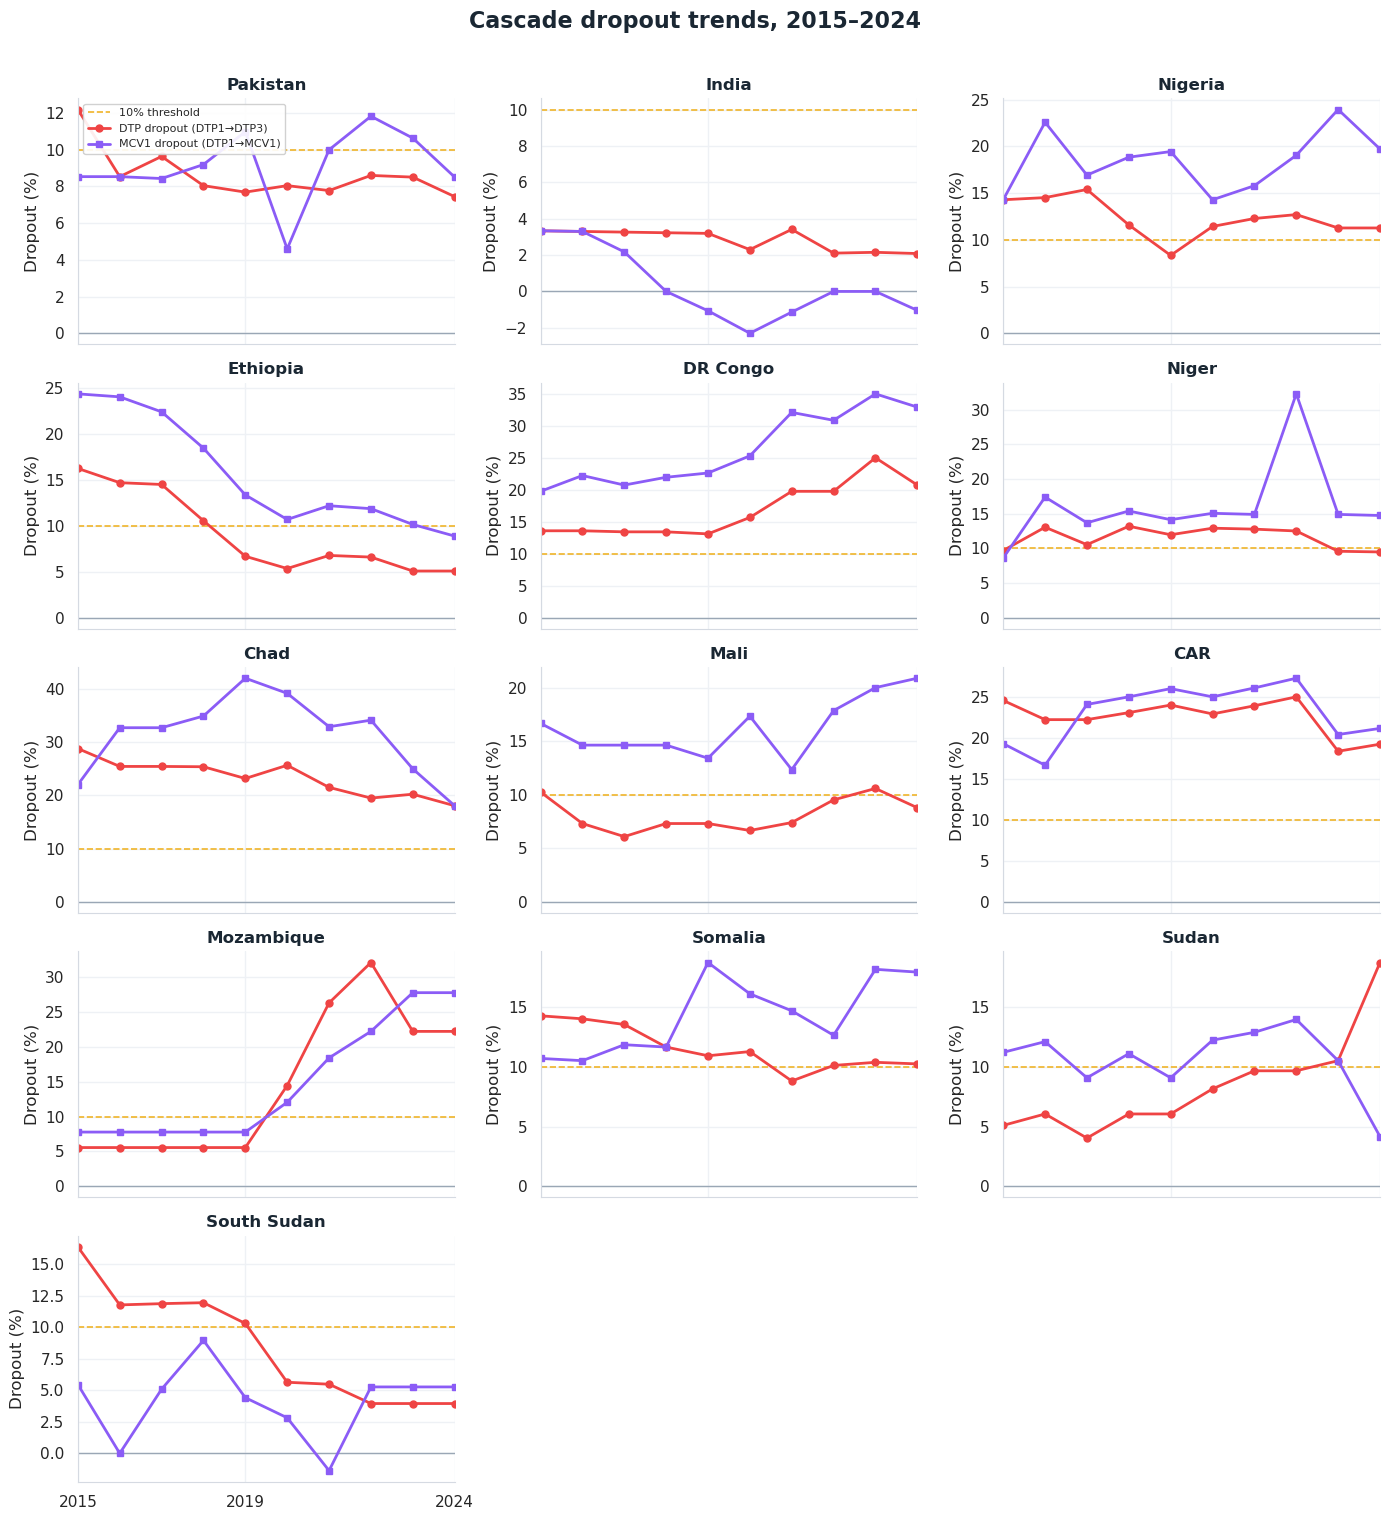

In [41]:
# ---------- cascade dropout charts ----------
C_DTP, C_MCV = '#ef4444', '#8b5cf6'

# Pivot to wide (Country-Year grain) so the antigens sit side by side
wide = (df[df['Year'].between(START, END)]
        .pivot_table(index=['Country', 'Year'], columns='Vaccine', values='WUENIC'))

# Positive-dropout convention: fraction of the DTP1 cohort lost by the later dose.
# (This is the sign we used earlier. To flip to your literal formula, swap the
#  two terms in each numerator, e.g. (wide['DTP3'] - wide['DTP1']).)
wide['dtp_dropout'] = (wide['DTP1'] - wide['DTP3']) / wide['DTP1'] * 100
wide['mcv_dropout'] = (wide['DTP1'] - wide['MCV1']) / wide['DTP1'] * 100
wide = wide.reset_index()

ncols = 3
nrows = int(np.ceil(len(COUNTRIES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.0 * nrows), sharex=True)
axes = np.array(axes).ravel()

for ax, (label, full) in zip(axes, COUNTRIES.items()):
    s = wide[wide['Country'] == full].sort_values('Year')
    ax.axhline(0, color='#9aa7b5', lw=1, zorder=1)
    ax.axhline(10, color='#f0b429', lw=1.2, ls='--', zorder=1, label='10% threshold')
    ax.plot(s['Year'], s['dtp_dropout'], 'o-', color=C_DTP, lw=2, ms=5,
            label='DTP dropout (DTP1→DTP3)')
    ax.plot(s['Year'], s['mcv_dropout'], 's-', color=C_MCV, lw=2, ms=5,
            label='MCV1 dropout (DTP1→MCV1)')
    ax.set_title(label, fontsize=12, fontweight='bold', color='#1a2733')
    ax.set_xlim(START, END)
    ax.set_ylabel('Dropout (%)')
    ax.set_xticks([START, (START + END) // 2, END])

for ax in axes[len(COUNTRIES):]:
    ax.set_visible(False)

axes[0].legend(fontsize=8, loc='upper left', framealpha=0.9)
fig.suptitle('Cascade dropout trends, 2015–2024', fontsize=16, fontweight='bold',
             color='#1a2733', y=1.01)
fig.tight_layout()
fig.savefig(OUT / 'dropout_panel_all_countries.png', dpi=200, bbox_inches='tight')
plt.show()

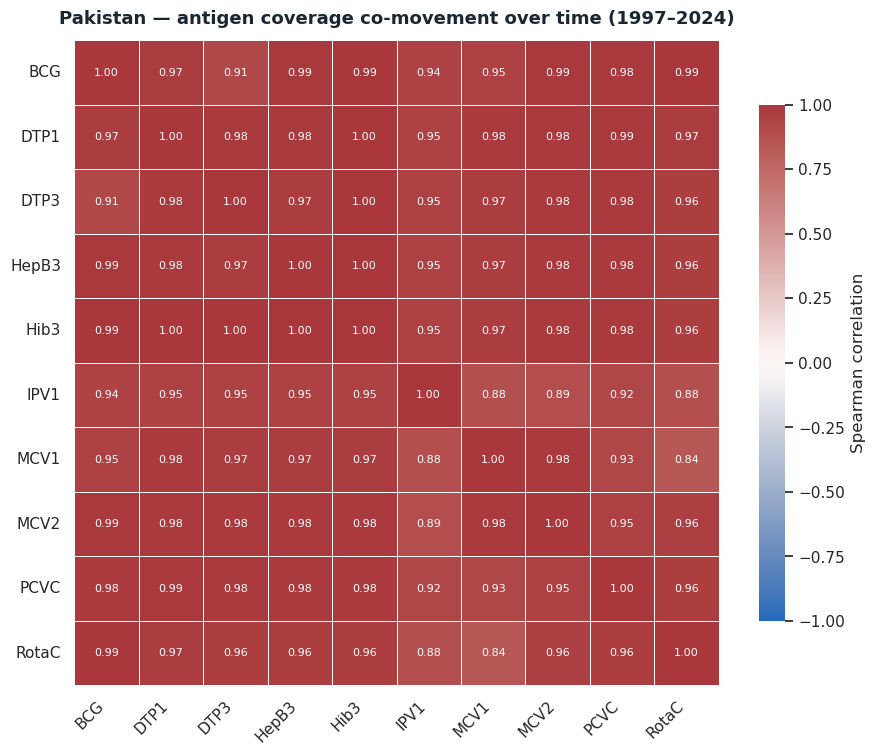

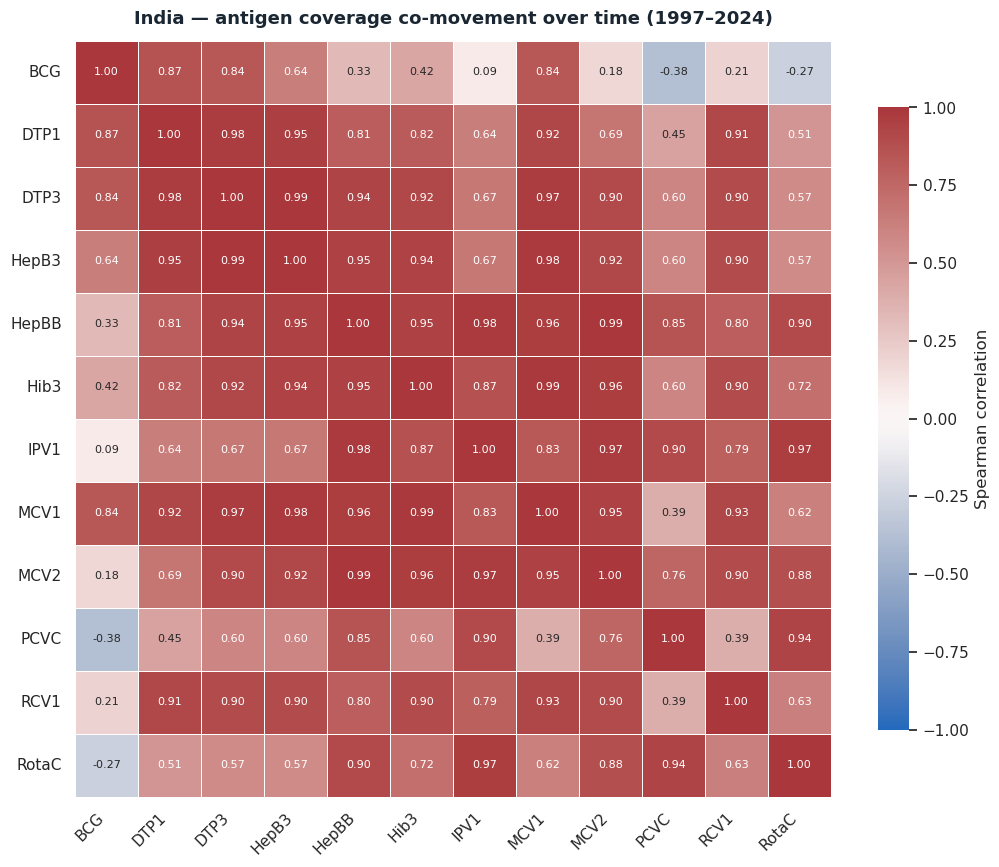

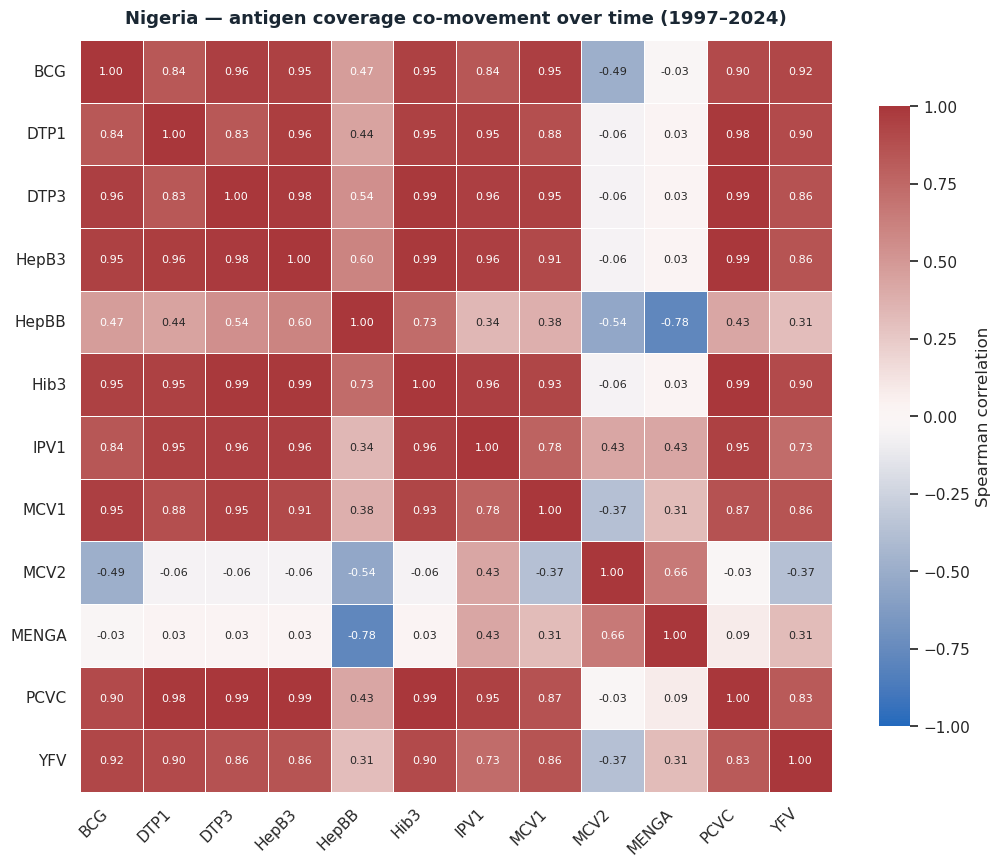

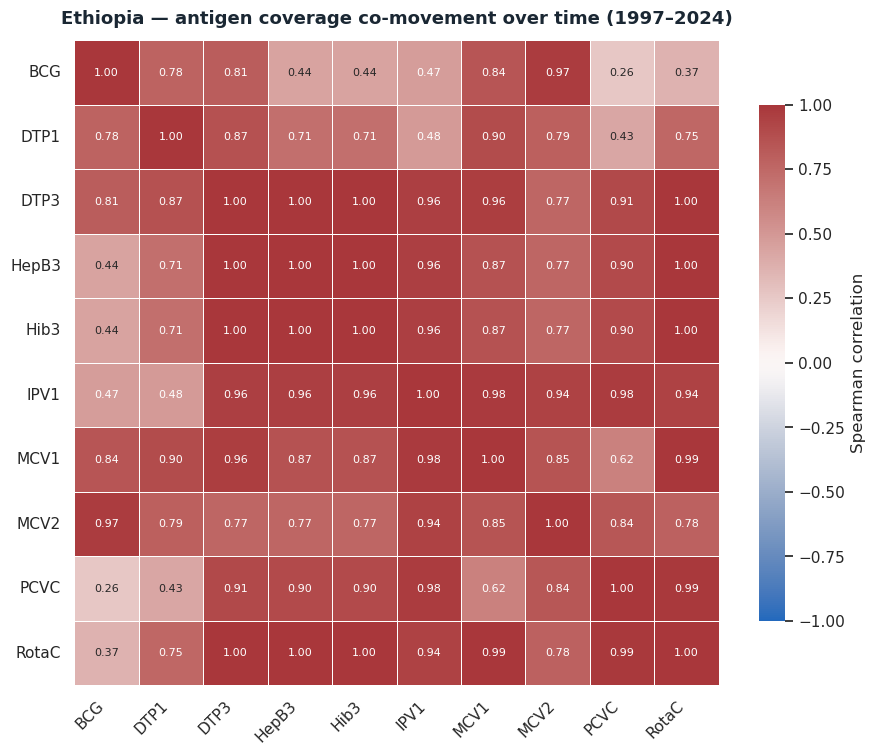

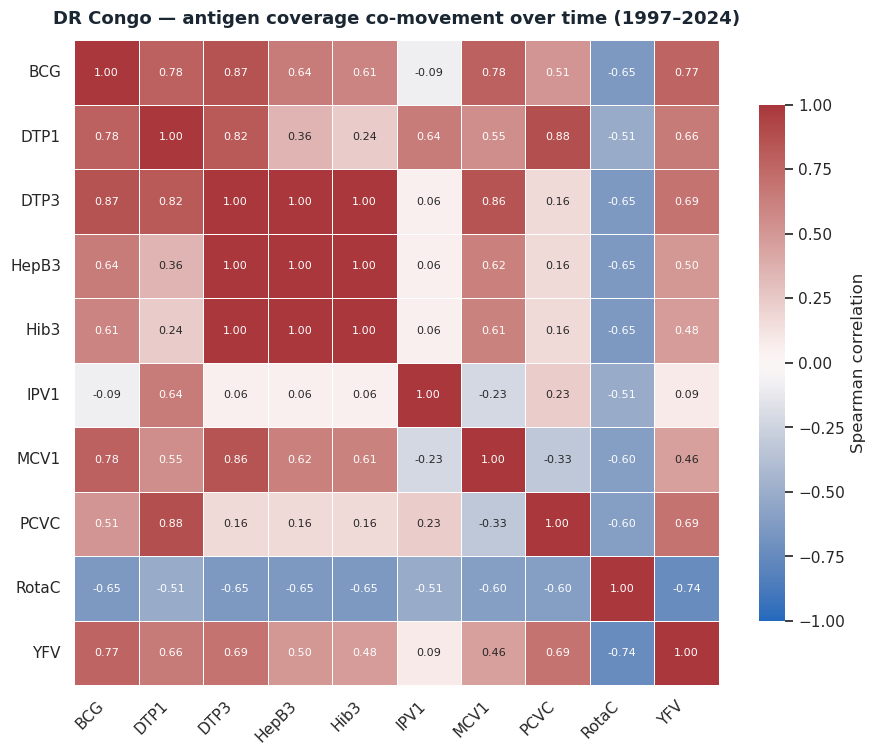

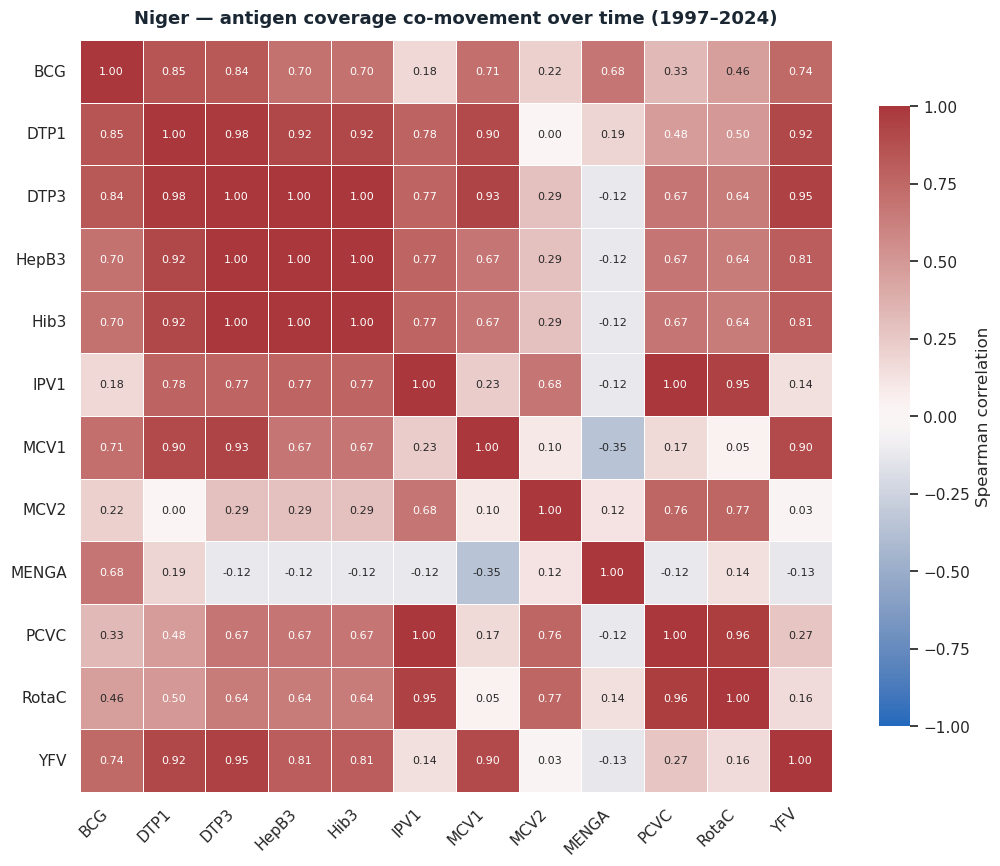

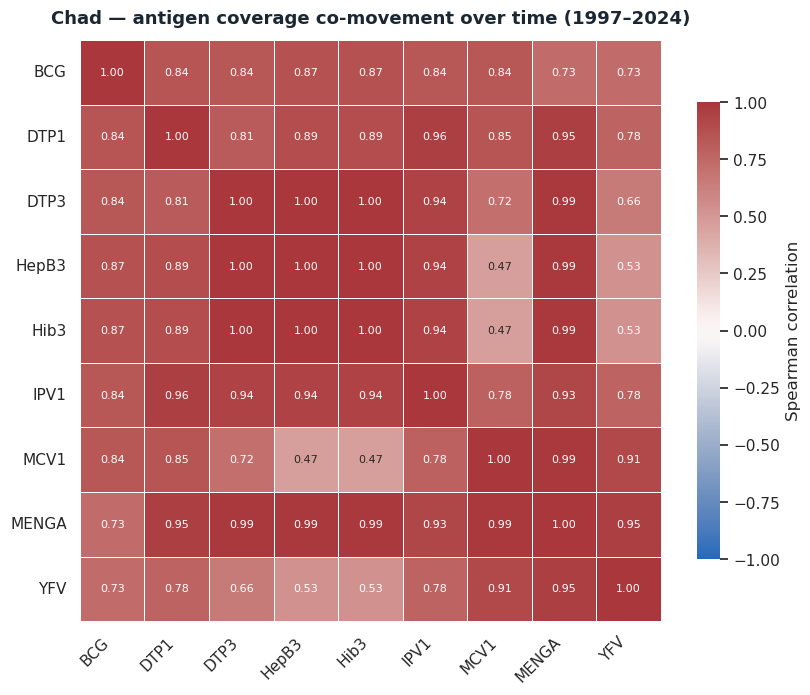

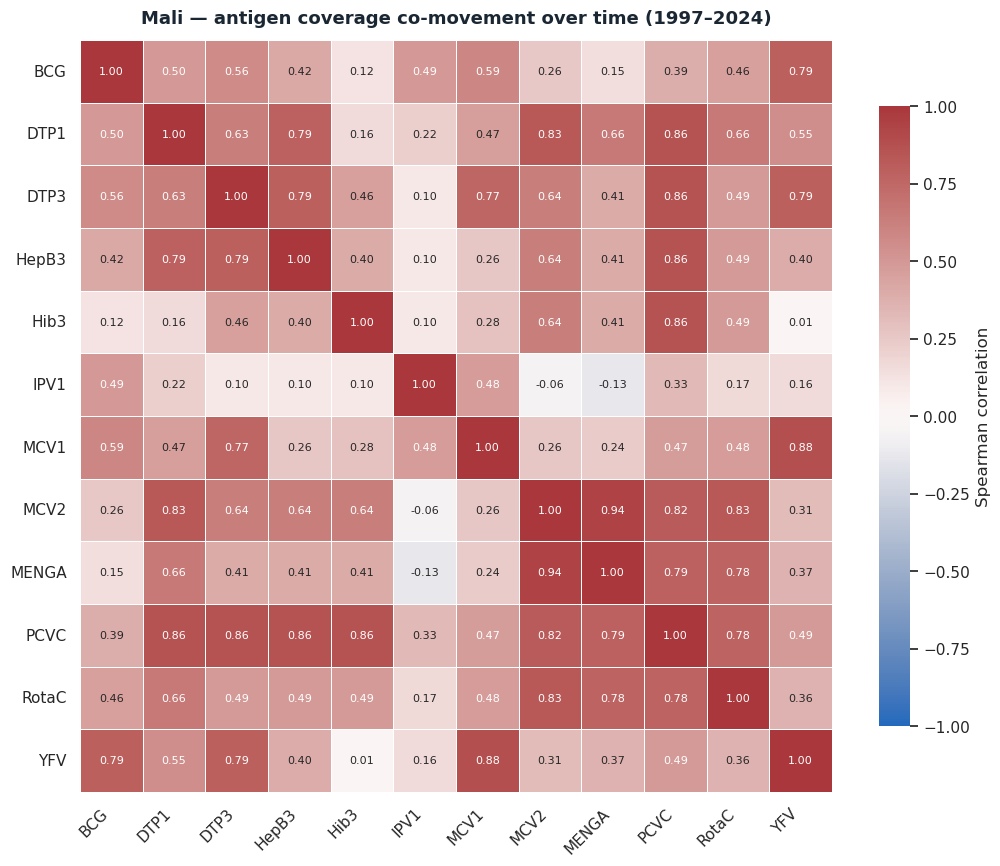

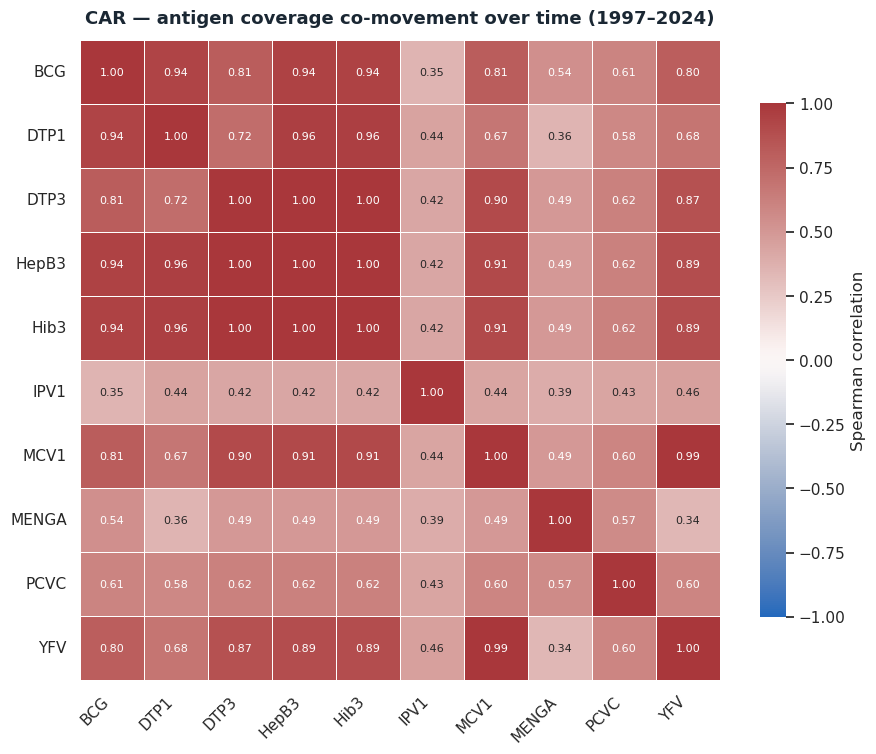

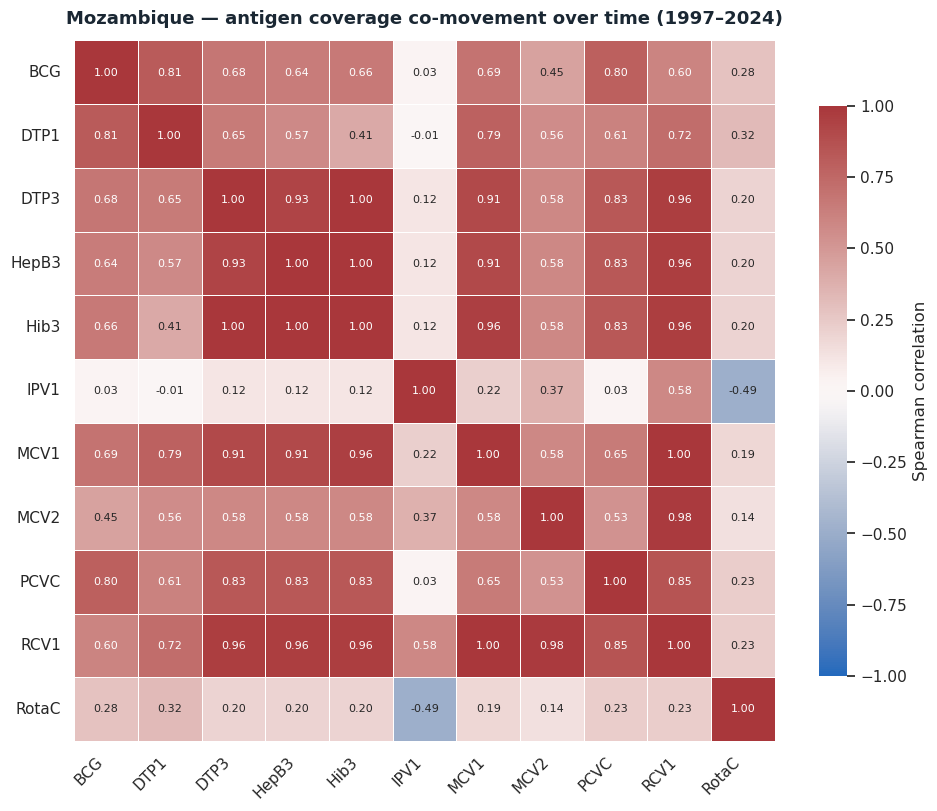

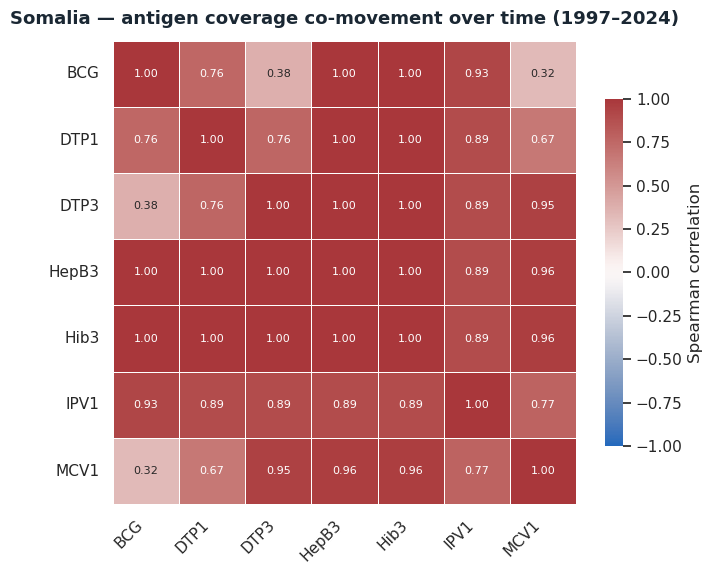

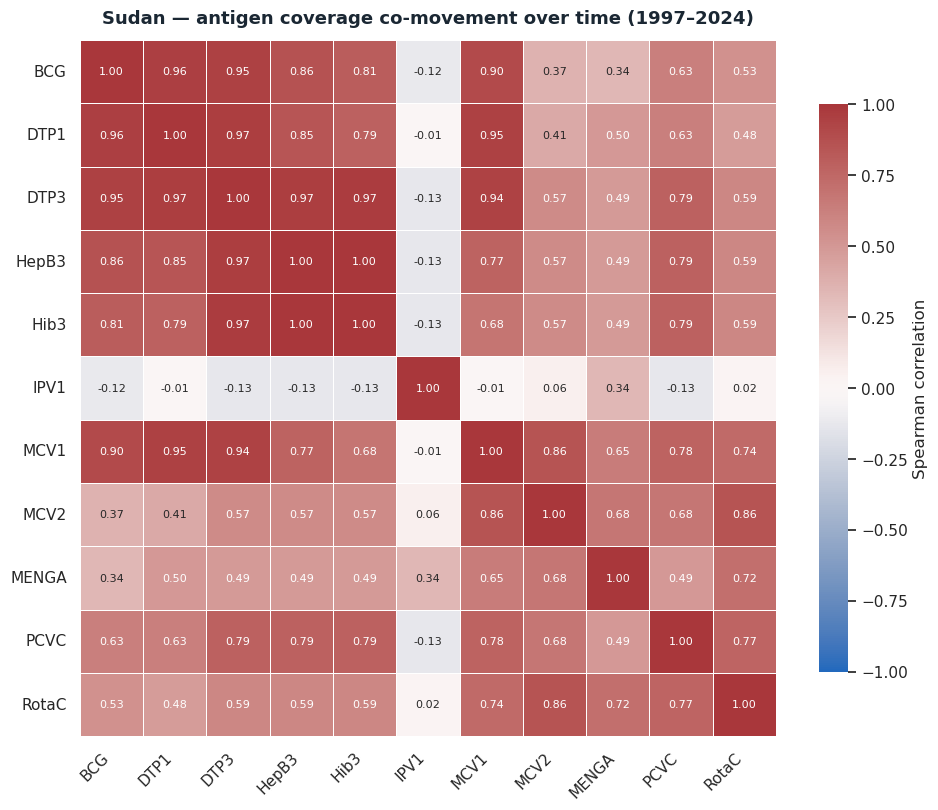

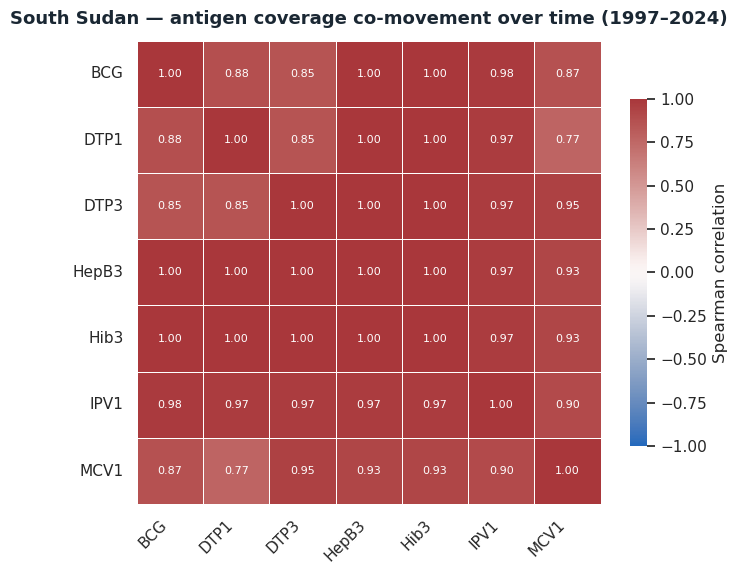

Saved 13 correlation heatmaps to C:\Users\kellyja\Documents\Projects\Ubiquitous\Projects\WUENIC 2026\charts


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUT = Path('charts'); OUT.mkdir(exist_ok=True)

COUNTRIES = {
    'Pakistan': 'Pakistan', 'India': 'India', 'Nigeria': 'Nigeria',
    'Ethiopia': 'Ethiopia', 'DR Congo': 'Democratic Republic of the Congo',
    'Niger': 'Niger', 'Chad': 'Chad', 'Mali': 'Mali',
    'CAR': 'Central African Republic', 'Mozambique': 'Mozambique',
    'Somalia': 'Somalia', 'Sudan': 'Sudan', 'South Sudan': 'South Sudan',
}

def plot_country_corr(country_full, country_label, start=1997, end=2024,
                      method='spearman', min_years=5):
    sub = df[(df['Country'] == country_full) & (df['Year'].between(start, end))]

    # rows = years, cols = antigens  -> correlate antigens ACROSS TIME
    mat = sub.pivot_table(index='Year', columns='Vaccine', values='WUENIC')

    # keep only antigens with enough years and some variation (else corr is NaN/unstable)
    keep = [c for c in mat.columns
            if mat[c].notna().sum() >= min_years and mat[c].nunique() > 1]
    mat = mat[sorted(keep)]

    corr = mat.corr(method=method)     # pairwise-complete by default

    fig, ax = plt.subplots(figsize=(0.7 * len(corr) + 2, 0.7 * len(corr) + 1))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.7, 'label': f'{method.title()} correlation'},
                annot_kws={'size': 8}, ax=ax)
    ax.set_title(f"{country_label} — antigen coverage co-movement over time ({start}–{end})",
                 fontsize=13, fontweight='bold', color='#1a2733', pad=12)
    ax.set_xlabel(''); ax.set_ylabel('')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    fig.tight_layout()
    return fig

for label, full in COUNTRIES.items():
    fig = plot_country_corr(full, label)
    fig.savefig(OUT / f"corr_{label.replace(' ', '_')}.png", dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
print(f"Saved {len(COUNTRIES)} correlation heatmaps to {OUT.resolve()}")

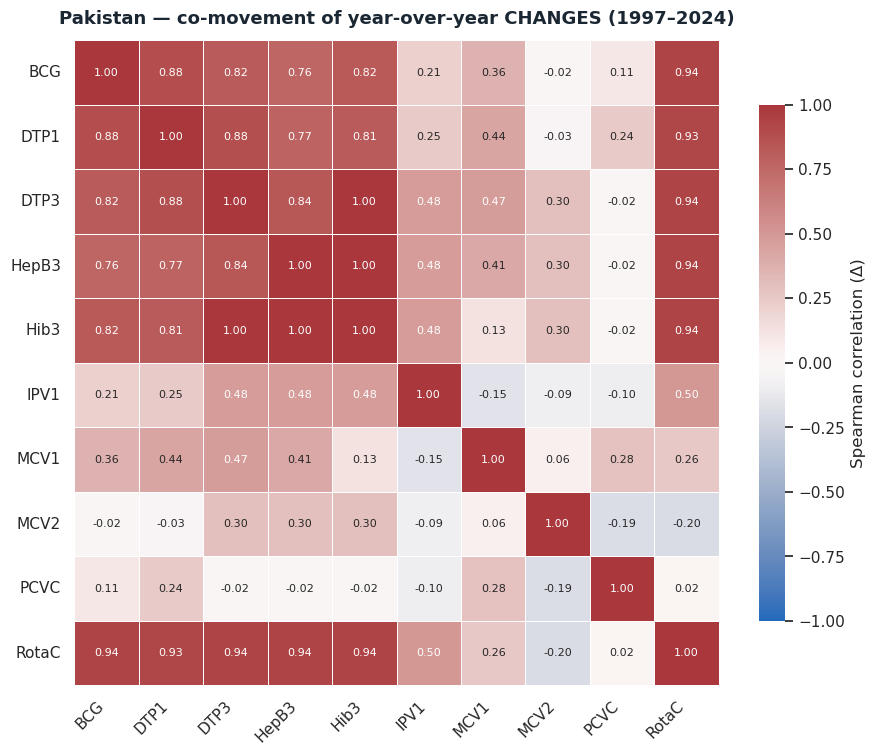

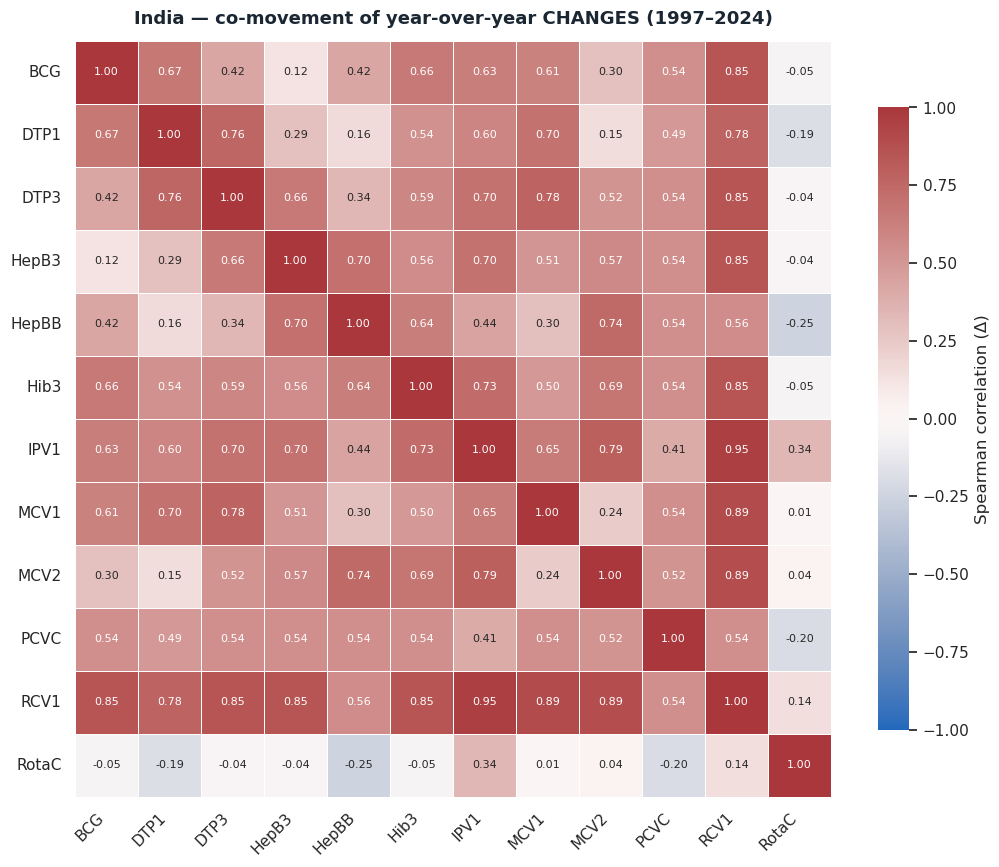

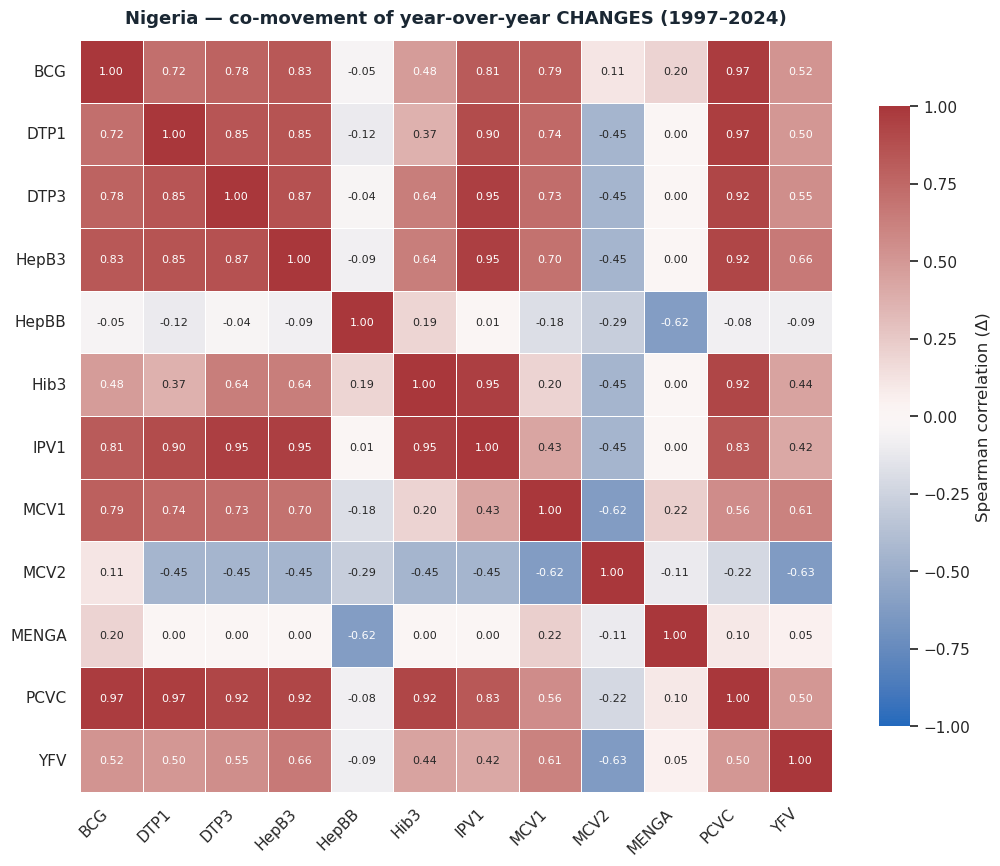

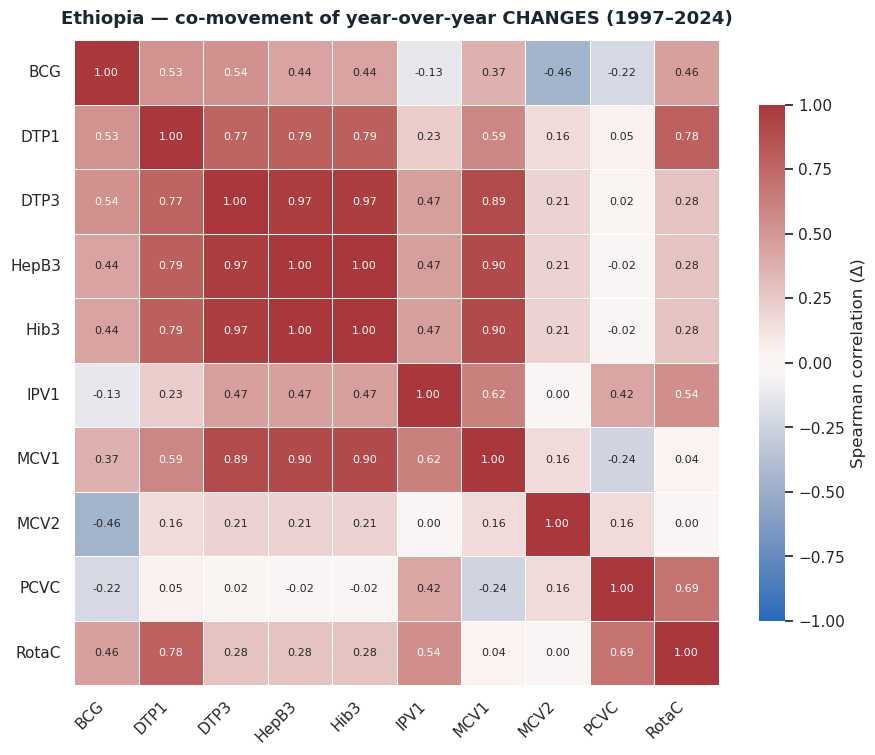

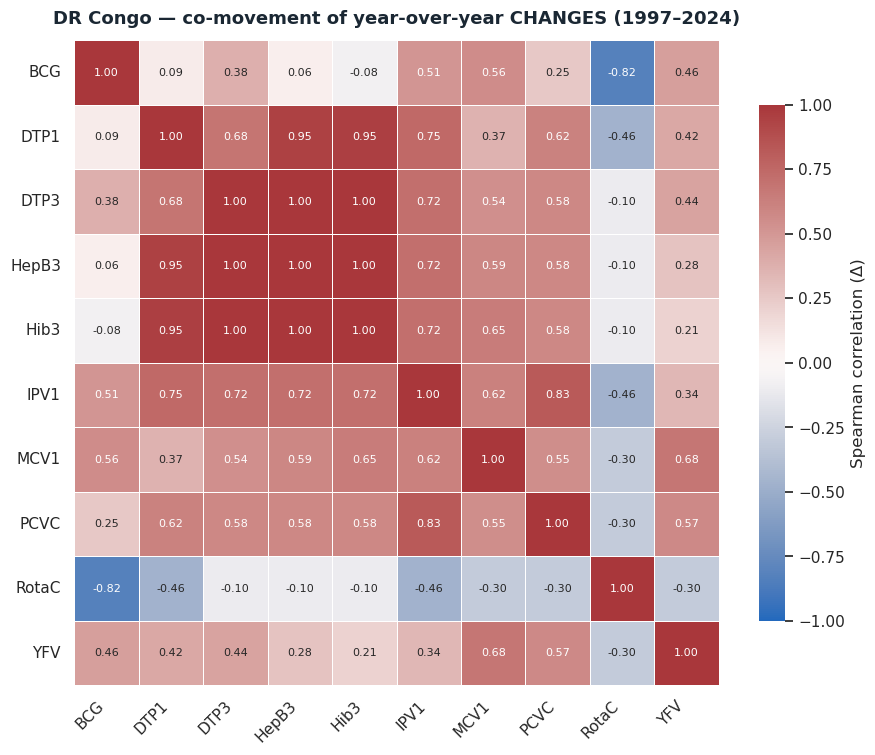

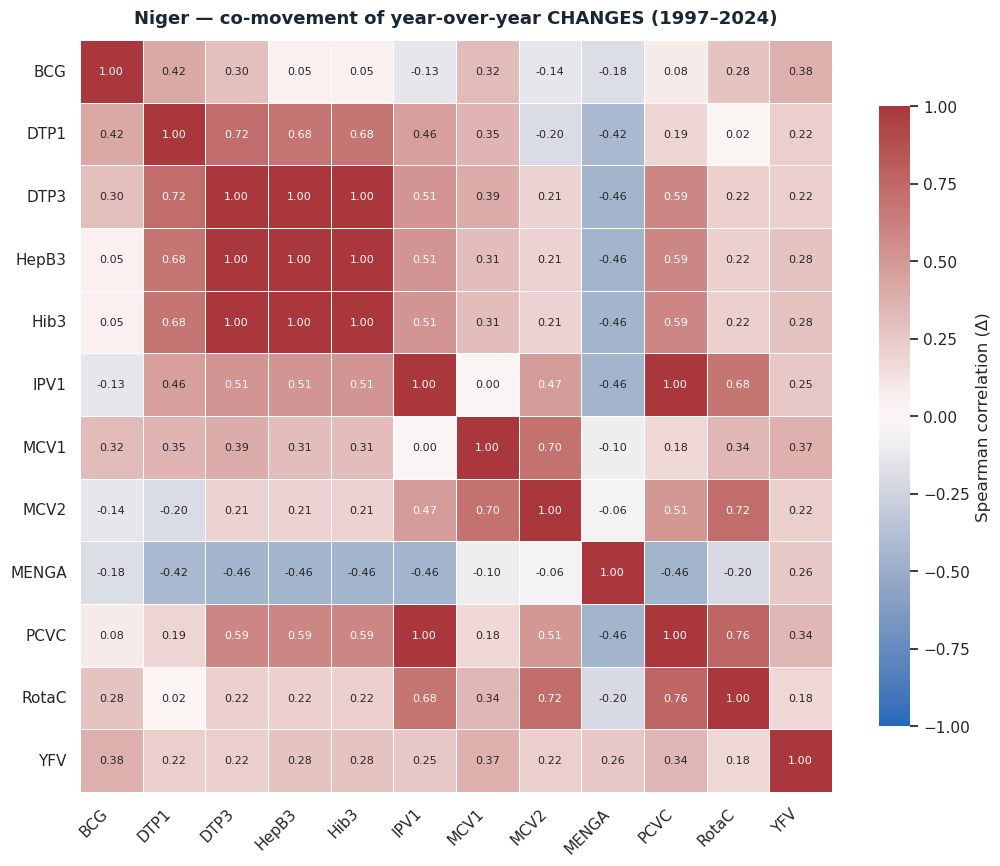

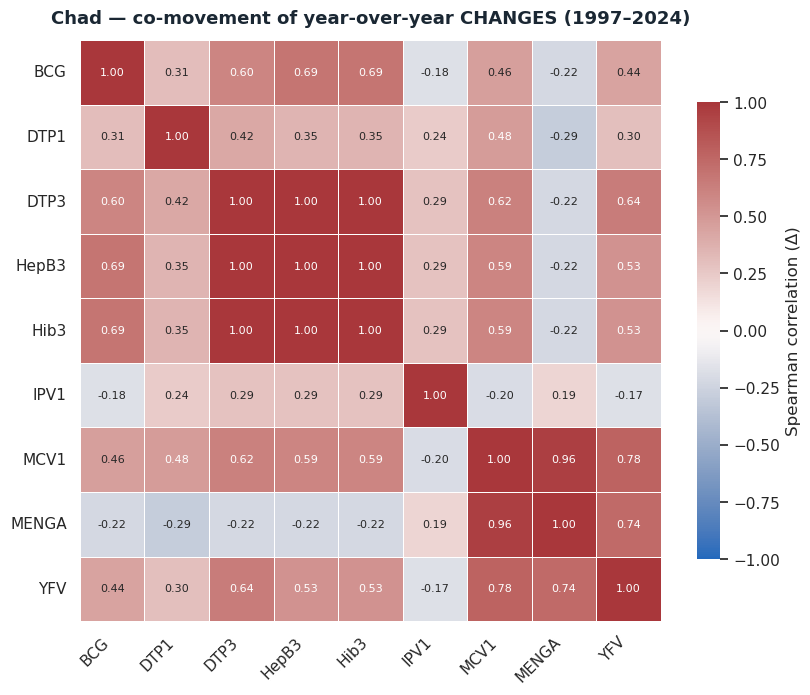

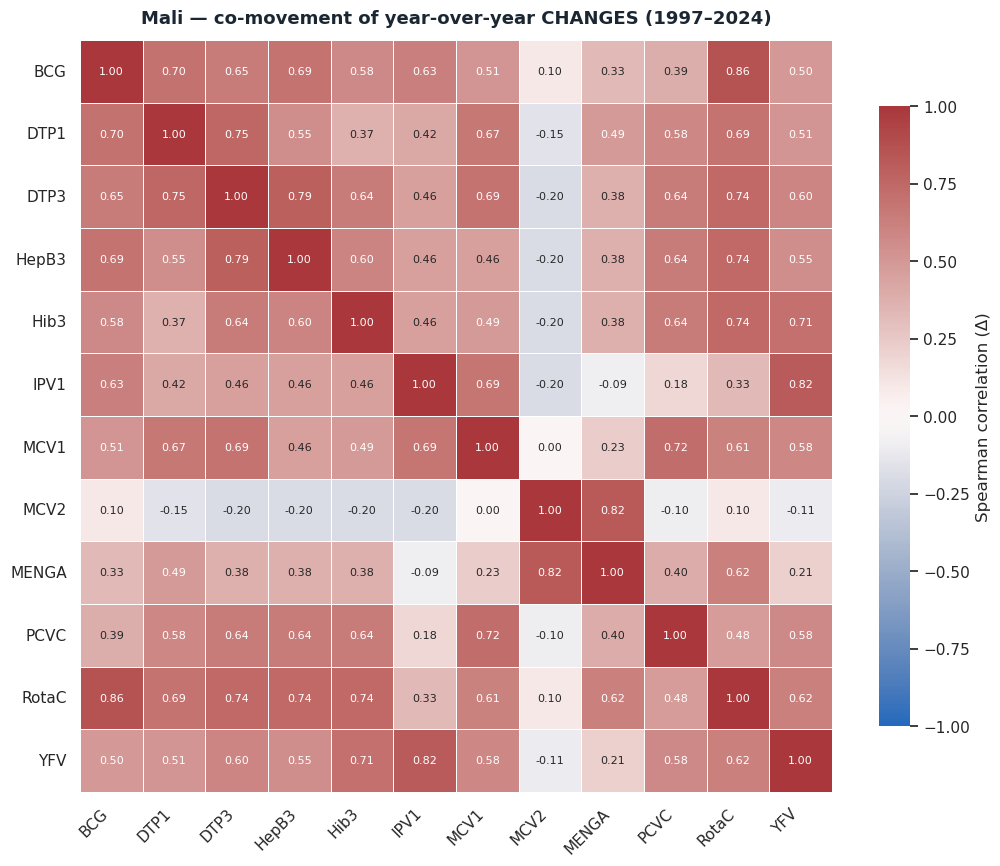

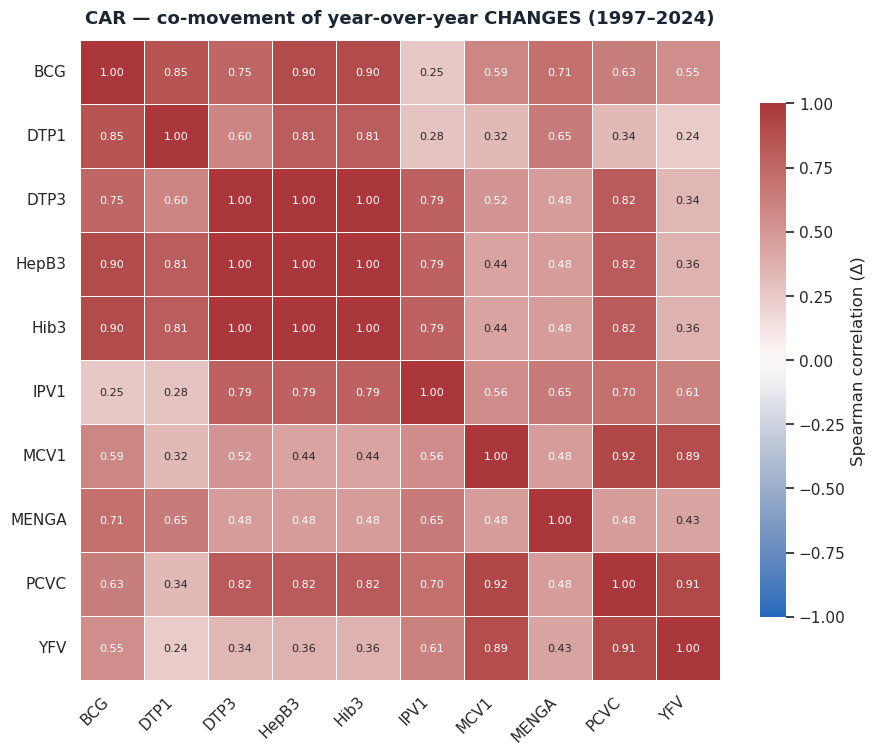

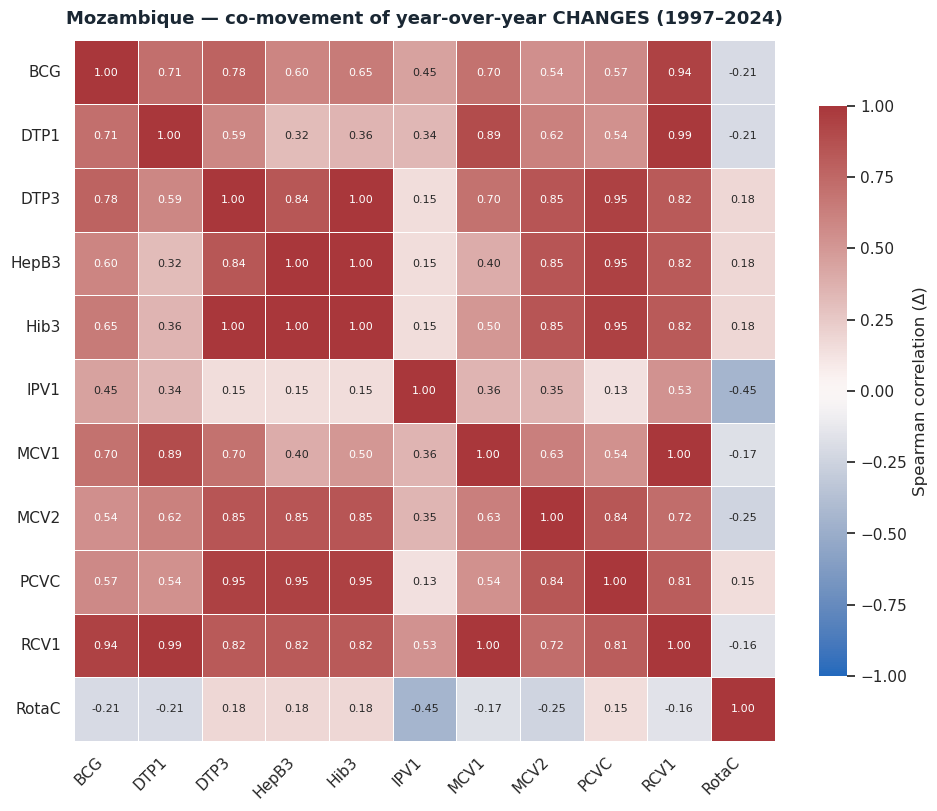

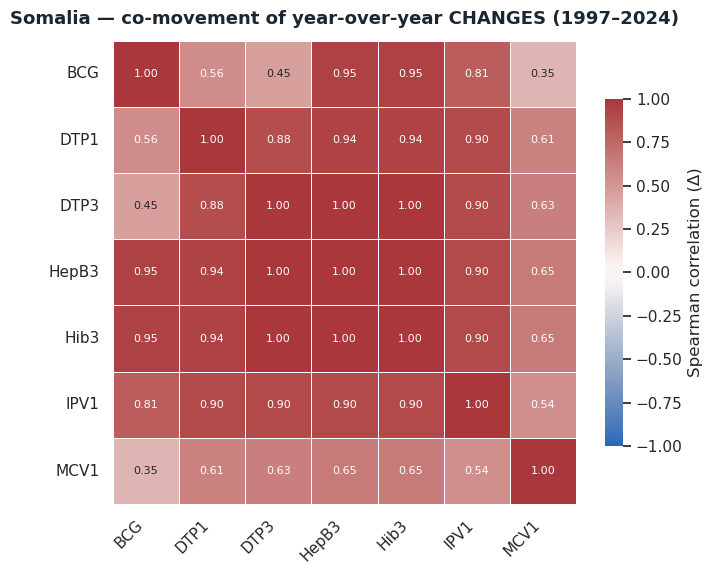

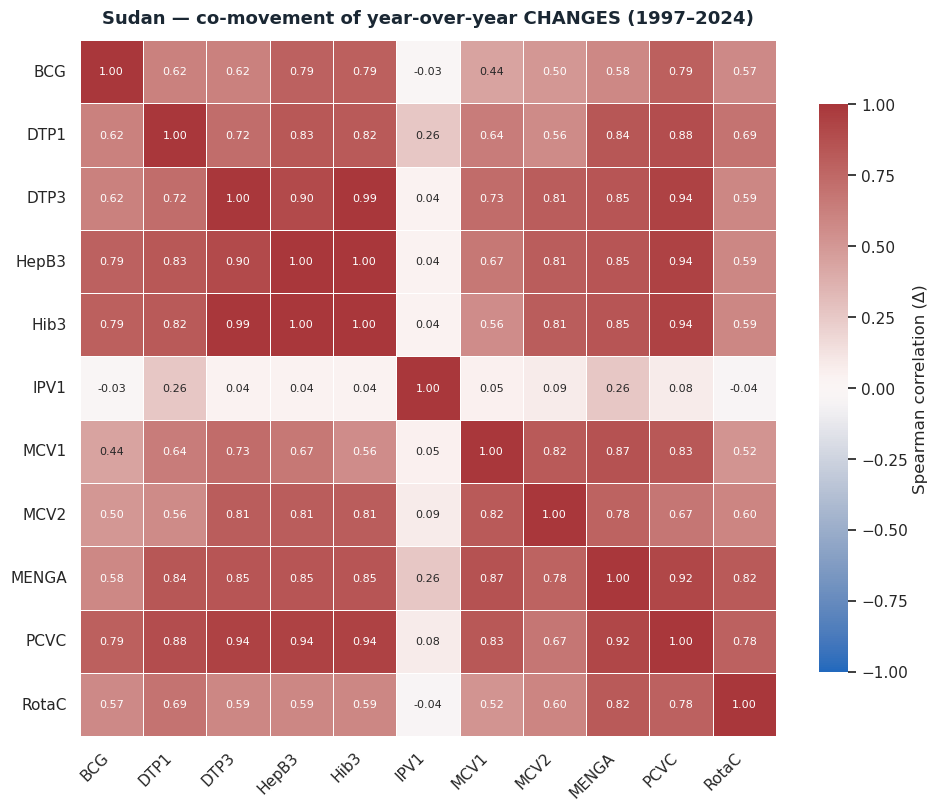

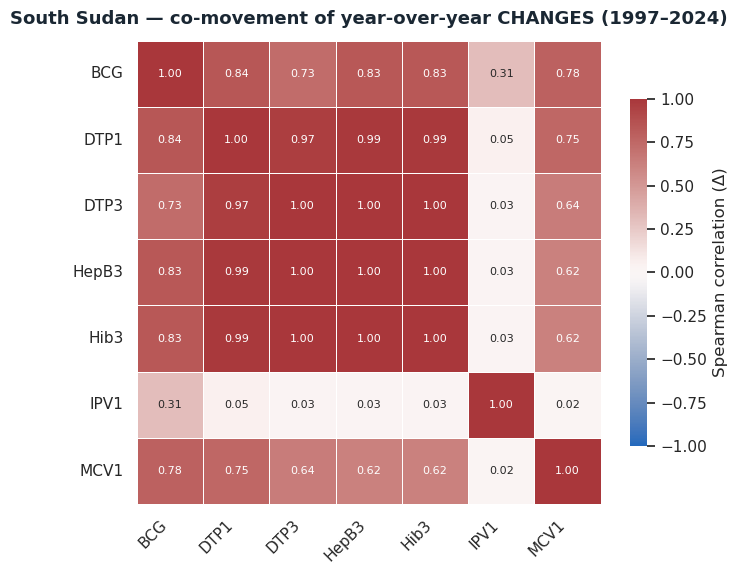

Saved 13 delta correlation heatmaps to C:\Users\kellyja\Documents\Projects\Ubiquitous\Projects\WUENIC 2026\charts


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUT = Path('charts'); OUT.mkdir(exist_ok=True)

COUNTRIES = {
    'Pakistan': 'Pakistan', 'India': 'India', 'Nigeria': 'Nigeria',
    'Ethiopia': 'Ethiopia', 'DR Congo': 'Democratic Republic of the Congo',
    'Niger': 'Niger', 'Chad': 'Chad', 'Mali': 'Mali',
    'CAR': 'Central African Republic', 'Mozambique': 'Mozambique',
    'Somalia': 'Somalia', 'Sudan': 'Sudan', 'South Sudan': 'South Sudan',
}

def plot_country_corr_delta(country_full, country_label, start=1997, end=2024,
                            method='spearman', min_years=5):
    sub = df[(df['Country'] == country_full) & (df['Year'].between(start, end))]

    # rows = years, cols = antigens
    mat = sub.pivot_table(index='Year', columns='Vaccine', values='WUENIC').sort_index()
    mat = mat.diff()                      # year-over-year change; removes shared trend

    # keep antigens with enough non-null changes and some variation
    keep = [c for c in mat.columns
            if mat[c].notna().sum() >= min_years and mat[c].nunique() > 1]
    mat = mat[sorted(keep)]

    corr = mat.corr(method=method)

    fig, ax = plt.subplots(figsize=(0.7 * len(corr) + 2, 0.7 * len(corr) + 1))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.7, 'label': f'{method.title()} correlation (Δ)'},
                annot_kws={'size': 8}, ax=ax)
    ax.set_title(f"{country_label} — co-movement of year-over-year CHANGES ({start}–{end})",
                 fontsize=13, fontweight='bold', color='#1a2733', pad=12)
    ax.set_xlabel(''); ax.set_ylabel('')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    fig.tight_layout()
    return fig

for label, full in COUNTRIES.items():
    fig = plot_country_corr_delta(full, label)
    fig.savefig(OUT / f"corr_delta_{label.replace(' ', '_')}.png", dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
print(f"Saved {len(COUNTRIES)} delta correlation heatmaps to {OUT.resolve()}")

In [47]:
mat = sub.pivot_table(index='Year', columns='Vaccine', values='WUENIC').sort_index()
    mat = mat.diff()          # <-- year-over-year change; removes the shared trend
    keep = [c for c in mat.columns
            if mat[c].notna().sum() >= min_years and mat[c].nunique() > 1]
    corr = mat[sorted(keep)].corr(method=method)

IndentationError: unexpected indent (3448785629.py, line 2)